# Project 1 — Dirichlet–Neumann iteration

We solve the three subdomain Laplace problems with second-order finite differences. The main run uses $h=1/20$, $\omega=0.8$, and ten iterations.

In [1]:
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

from solver import (
    assemble_apartment,
    dirichlet_matrix,
    neumann_matrix,
)

# Defining the constants
N = 20
H = 1 / N
OMEGA = 0.8
ITERATIONS = 10
WALL_TEMPERATURE = 15.0
HEATER_TEMPERATURE = 40.0
WINDOW_TEMPERATURE = 5.0
COMFORT_TEMPERATURE = 18.0
PLOT_MAX_TEMPERATURE = 60.0

# For plotting. Areas below 18°C are plotted in blue while those above 18°C are plotted in red
TEMPERATURE_LEVELS = np.arange(WINDOW_TEMPERATURE, PLOT_MAX_TEMPERATURE + 1)
TEMPERATURE_NORM = TwoSlopeNorm(
    vmin=WINDOW_TEMPERATURE,
    vcenter=COMFORT_TEMPERATURE,
    vmax=PLOT_MAX_TEMPERATURE,
)

# Max temperature set to 60°C for task 4
TEMPERATURE_TICKS = [5, 18, 30, 45, 60]

## Grid and ordering

Before we start, we fix some conventions here. 

We use Numpy arrays for our grid data. Array rows follow increasing $y$, columns follow increasing $x$. And when we flatten the array to solve the linear system, we use row-major ordering (C-style).

The endpoints of each interface ($\Gamma_1$ and $\Gamma_2$) are assigned to the temperature of the adjacent walls. When two exterior walls with different temperatures meet, we set the shared corner value to their average.

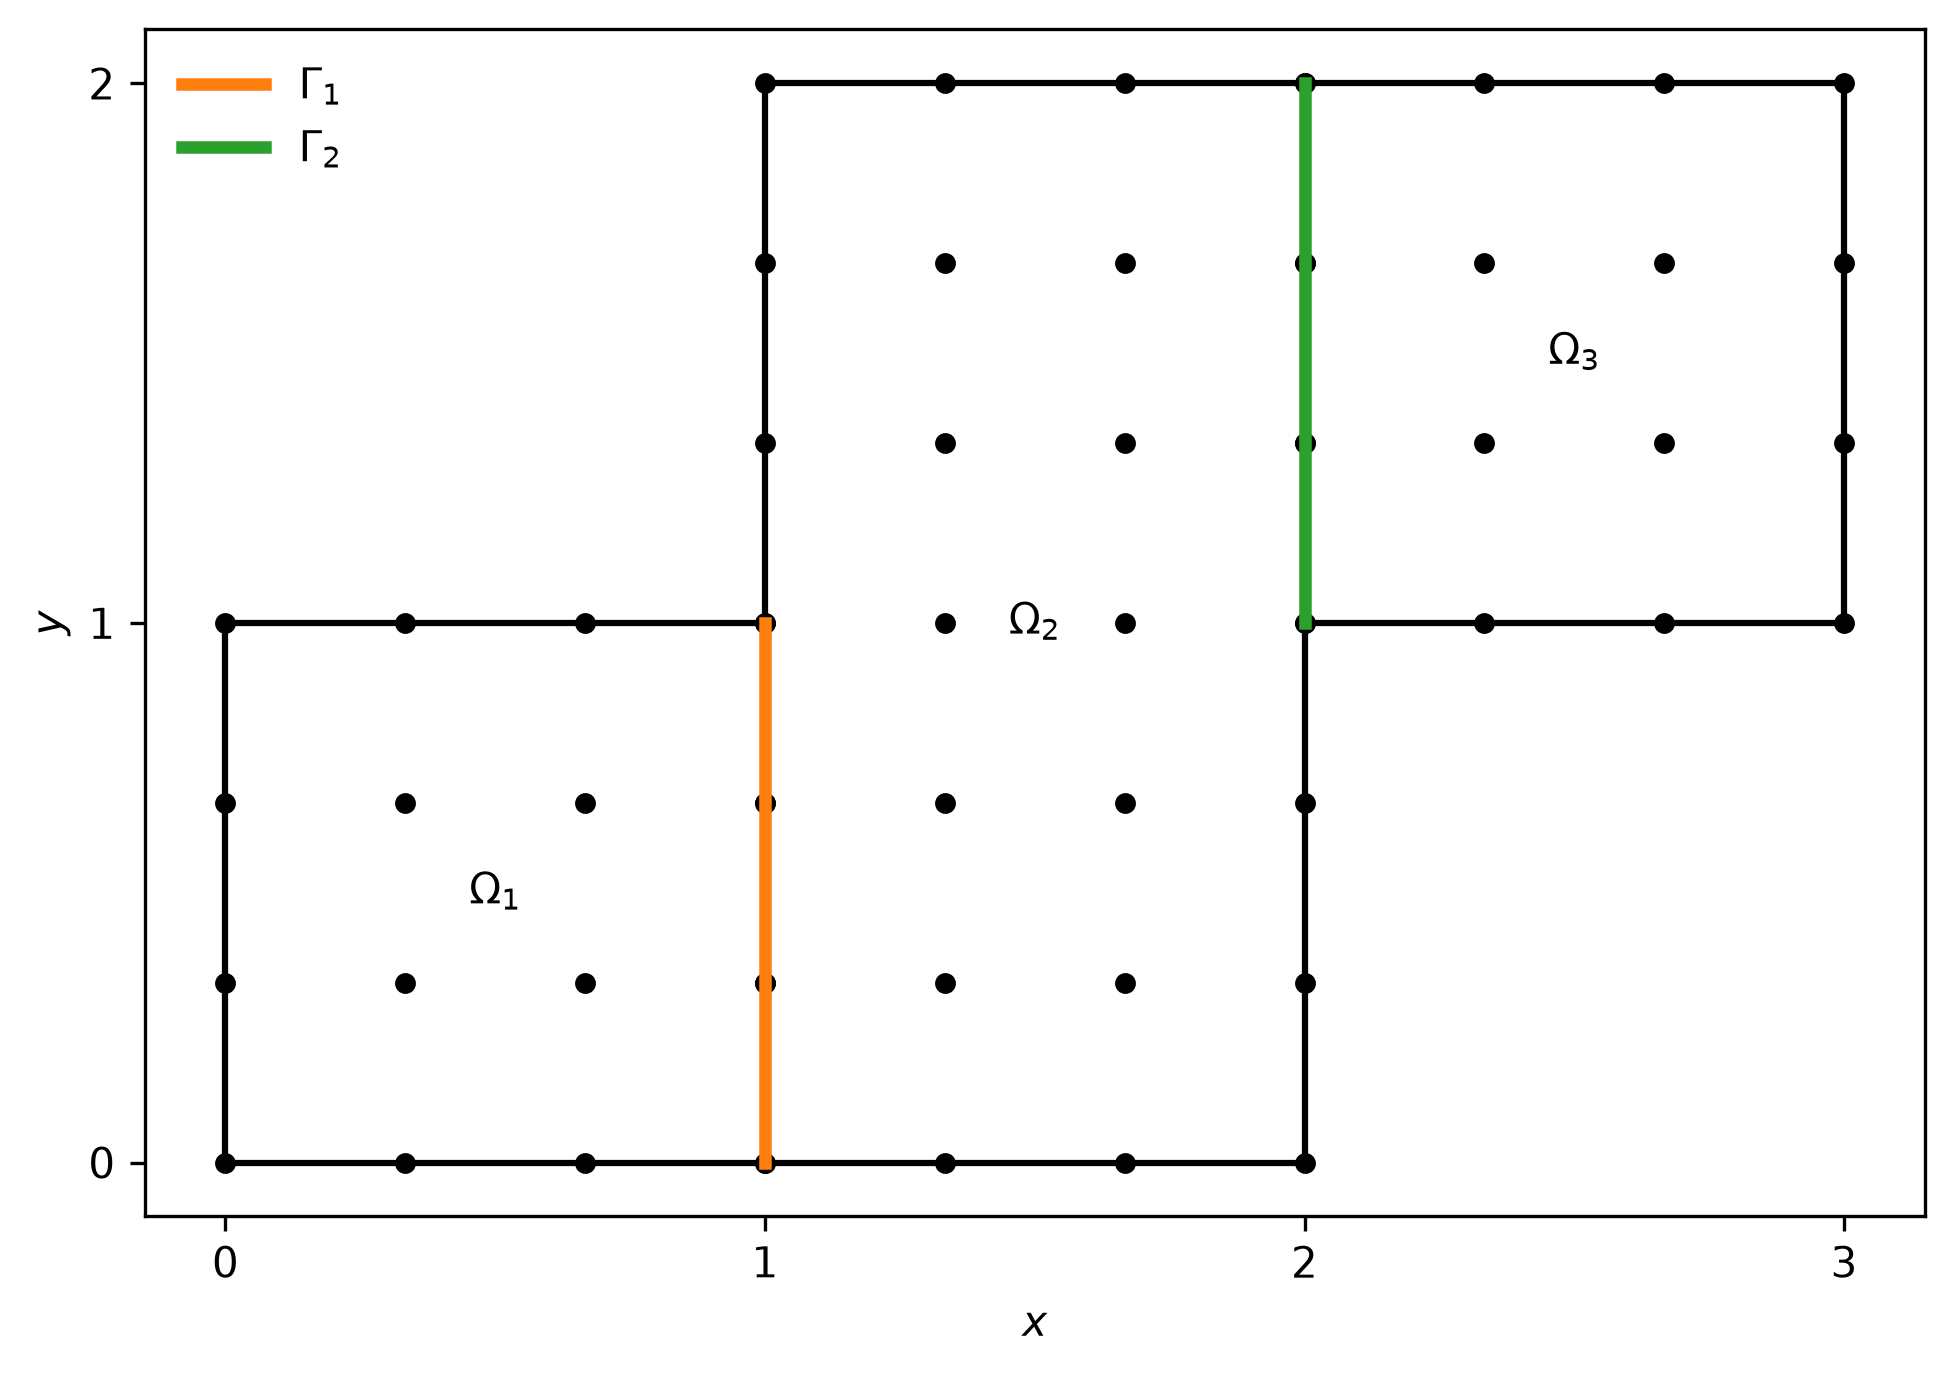

In [2]:
h_small = 1 / 3 # For task 1 and visualization, we use a different h here
fig, ax = plt.subplots(dpi=300, layout="constrained")

# Init the room grids
rooms = [
    (0, 1, 0, 1, r"$\Omega_1$"),
    (1, 2, 0, 2, r"$\Omega_2$"),
    (2, 3, 1, 2, r"$\Omega_3$"),
]
for x0, x1, y0, y1, label in rooms:
    x = np.arange(x0, x1 + h_small / 2, h_small)
    y = np.arange(y0, y1 + h_small / 2, h_small)
    X, Y = np.meshgrid(x, y)
    ax.scatter(X, Y, s=16, color="black")
    ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], color="black")
    ax.text((x0 + x1) / 2, (y0 + y1) / 2, label, ha="center", va="center")

# Visualization the grid for task 1
ax.plot([1, 1], [0, 1], linewidth=3, color="tab:orange", label=r"$\Gamma_1$")
ax.plot([2, 2], [1, 2], linewidth=3, color="tab:green", label=r"$\Gamma_2$")
ax.set(xlabel="$x$", ylabel="$y$", xticks=np.arange(4), yticks=np.arange(3))
ax.set_aspect("equal")
ax.legend(frameon=False)
plt.show()

## Task 1 — matrices for $h=1/3$

Let $u^{(r)}_{i,j}$ denote the temperature at node $(i,j)$ in $\Omega_r$. We write $g_1^k$ and $g_2^k$ for the interface temperatures at iteration $k$, and $q_1$ and $q_3$ for the outward fluxes (the normal derivatives) used by the two outer rooms. We take the outward normal as the positive direction when evaluating the Neumann boundary condition for each outer room, so the same discrete form can be used at both interfaces.

### Boundary conditions in the three rooms

The middle room $\Omega_2$ uses Dirichlet conditions on both interfaces:
$$
u^{(2)}|_{\Gamma_1}=g_1^k,
\qquad
u^{(2)}|_{\Gamma_2}=g_2^k.
$$
Here, $g_1^k$ and $g_2^k$ come from the current solutions in $\Omega_1$ and $\Omega_3$.

The outer rooms use Neumann conditions on their interfaces:
$$
\frac{\partial u^{(1)}}{\partial \boldsymbol n_1}=q_1
\quad\text{on }\Gamma_1,
\qquad
\frac{\partial u^{(3)}}{\partial \boldsymbol n_3}=q_3
\quad\text{on }\Gamma_2.
$$
The fluxes are calculated from the new solution in $\Omega_2$. Their signs are changed when they are transferred because the outward normals of two neighbouring rooms point in opposite directions.

All exterior walls have known Dirichlet values: 15°C on normal walls, 40°C on heater walls, and 5°C on the window. We remove all fixed nodes with known dirichlet conditions from the unknown vectors and move their contributions to the right-hand side of the linear system.

### Rows of the matrices

For an interior node, multiplying the discrete Laplace equation by $-h^2$ gives
$$
4u_{i,j}-u_{i-1,j}-u_{i+1,j}-u_{i,j-1}-u_{i,j+1}=0.
$$
The corresponding matrix row has $4$ on the diagonal and $-1$ for every neighbouring unknown. If a neighbour is a Dirichlet node with value $T$, its contribution is added to the right-hand side as $+T$.

For a Neumann interface node, we use the discrete flux balance to estimate the laplacian equation. On the right edge of $\Omega_1$ it is
$$
\frac{1}{h}\left(
\frac{u^{(1)}_{N,j+1}-u^{(1)}_{N,j}}{h}
-\frac{u^{(1)}_{N,j}-u^{(1)}_{N,j-1}}{h}
+q_{1,j}
-\frac{u^{(1)}_{N,j}-u^{(1)}_{N-1,j}}{h}
\right)=0.
$$
After multiplying by $-h^2$, this becomes
$$
3u^{(1)}_{N,j}
-u^{(1)}_{N,j+1}
-u^{(1)}_{N,j-1}
-u^{(1)}_{N-1,j}
=hq_{1,j}.
$$
The left edge of $\Omega_3$ has the same form, with $u^{(3)}_{1,j}$ as the neighbour inside the room:
$$
3u^{(3)}_{0,j}
-u^{(3)}_{0,j+1}
-u^{(3)}_{0,j-1}
-u^{(3)}_{1,j}
=hq_{3,j}.
$$
These flux-balance equations replace the Laplace rows at the Neumann interface nodes.

As we mentioned in the previous part, we use row-major ordering to arrange the unknowns in the linear system. For $\Omega_1$ and $\Omega_3$,
$$
v_1=(u^{(1)}_{1,1},u^{(1)}_{2,1},u^{(1)}_{3,1},
     u^{(1)}_{1,2},u^{(1)}_{2,2},u^{(1)}_{3,2})^T,
$$
$$
v_3=(u^{(3)}_{0,1},u^{(3)}_{1,1},u^{(3)}_{2,1},
     u^{(3)}_{0,2},u^{(3)}_{1,2},u^{(3)}_{2,2})^T.
$$
For $\Omega_2$,
$$
v_2=(u^{(2)}_{1,1},u^{(2)}_{2,1},
     u^{(2)}_{1,2},u^{(2)}_{2,2},\ldots,
     u^{(2)}_{1,5},u^{(2)}_{2,5})^T.
$$

Thus, in each room $\Omega_r$, we have a linear system of the form
$$
A_r v_r = b_r,
$$

where $A_r$ represents the discrete Laplace operator with the appropriate boundary conditions, $v_r$ is the vector of unknown temperatures, and $b_r$ is the right-hand side vector that includes contributions from Dirichlet boundary conditions and Neumann conditions. 

Detailed implementation of the construction of our linear systems and the solver itself can be found in [solver.py](solver.py).

In [3]:
# Construct A2 with Dirichlet conditions
A2_small = dirichlet_matrix(3, 6)

# Construct A1 and A3 with Neumann conditions
A1_small = neumann_matrix(3, "right")
A3_small = neumann_matrix(3, "left")


np.set_printoptions(linewidth=120, suppress=True)
print("A1 =")
print(A1_small)
print("\nA2 =")
print(A2_small)
print("\nA3 =")
print(A3_small)

A1 =
[[ 4. -1.  0. -1.  0.  0.]
 [-1.  4. -1.  0. -1.  0.]
 [ 0. -1.  3.  0.  0. -1.]
 [-1.  0.  0.  4. -1.  0.]
 [ 0. -1.  0. -1.  4. -1.]
 [ 0.  0. -1.  0. -1.  3.]]

A2 =
[[ 4. -1. -1.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  4.  0. -1.  0.  0.  0.  0.  0.  0.]
 [-1.  0.  4. -1. -1.  0.  0.  0.  0.  0.]
 [ 0. -1. -1.  4.  0. -1.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  4. -1. -1.  0.  0.  0.]
 [ 0.  0.  0. -1. -1.  4.  0. -1.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  4. -1. -1.  0.]
 [ 0.  0.  0.  0.  0. -1. -1.  4.  0. -1.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.  4. -1.]
 [ 0.  0.  0.  0.  0.  0.  0. -1. -1.  4.]]

A3 =
[[ 3. -1.  0. -1.  0.  0.]
 [-1.  4. -1.  0. -1.  0.]
 [ 0. -1.  4.  0.  0. -1.]
 [-1.  0.  0.  3. -1.  0.]
 [ 0. -1.  0. -1.  4. -1.]
 [ 0.  0. -1.  0. -1.  4.]]


## Dirichlet–Neumann iteration

Since the Jupyter kernel runs as a single MPI process, we put the 3-rank MPI code in a separate file [mpi_driver.py](mpi_driver.py), and call it with `mpiexec` from the notebook. The file contains the three-rank communication and iteration. The notebook and MPI driver use the same solver functions.

The full grids start at 15°C, after which the heater, window, and exterior wall values are imposed. Thus the initial Dirichlet trace on both artificial interfaces is also 15°C. Rank 0 solves $\Omega_2$; ranks 1 and 2 solve $\Omega_1$ and $\Omega_3$.

In [4]:
def run_case(
    output,
    n=N,
    omega=OMEGA,
    iterations=ITERATIONS,
    wall=WALL_TEMPERATURE,
    heater=HEATER_TEMPERATURE,
    window=WINDOW_TEMPERATURE,
):
    command = [
        "mpiexec", "-n", "3", sys.executable, "mpi_driver.py",
        "--n", str(n),
        "--omega", str(omega),
        "--iterations", str(iterations),
        "--wall", str(wall),
        "--heater", str(heater),
        "--window", str(window),
        "--output", output,
    ]
    run = subprocess.run(command, capture_output=True, text=True, check=True)
    print(run.stdout.strip())
    return np.load(output)


data = run_case("temperature_data.npz")

Saved temperature_data.npz after 10 iterations


## Task 2 — is the heating adequate?

The assignment handout gives no threshold for "adequate" heating. We use 18°C as a stated working threshold and inspect only interior apartment nodes. We say that the heating is adequate if the minimum temperature is at least 18°C.

The minimum, mean, and fraction below 18°C summarize the result.

In [5]:
def get_interior_values(u1, u2, u3):
    apartment = assemble_apartment(u1, u2, u3)
    present = np.isfinite(apartment)
    interior = present.copy()
    interior[[0, -1], :] = False
    interior[:, [0, -1]] = False
    interior &= (
        np.roll(present, 1, axis=0)
        & np.roll(present, -1, axis=0)
        & np.roll(present, 1, axis=1)
        & np.roll(present, -1, axis=1)
    )
    return apartment, apartment[interior]


u1, u2, u3 = data["u1"], data["u2"], data["u3"]
apartment, interior_values = get_interior_values(u1, u2, u3)

minimum = interior_values.min()
mean = interior_values.mean()
below_18 = np.mean(interior_values < 18.0)

print(f"Interior minimum: {minimum:.2f} °C")
print(f"Interior mean: {mean:.2f} °C")
print(f"Interior nodes below 18 °C: {below_18:.1%}")
print(f"Last interface update: {data['history'][-1]:.3f} °C")

Interior minimum: 5.96 °C
Interior mean: 19.89 °C
Interior nodes below 18 °C: 46.4%
Last interface update: 0.012 °C


The heating is not adequate under this criterion. Although the mean is close to 20°C, a substantial part of the apartment remains below 18°C, especially near the large window as shown in the temperature distribution in task 3 (so you better close it :/).

## Task 3 — temperature distribution

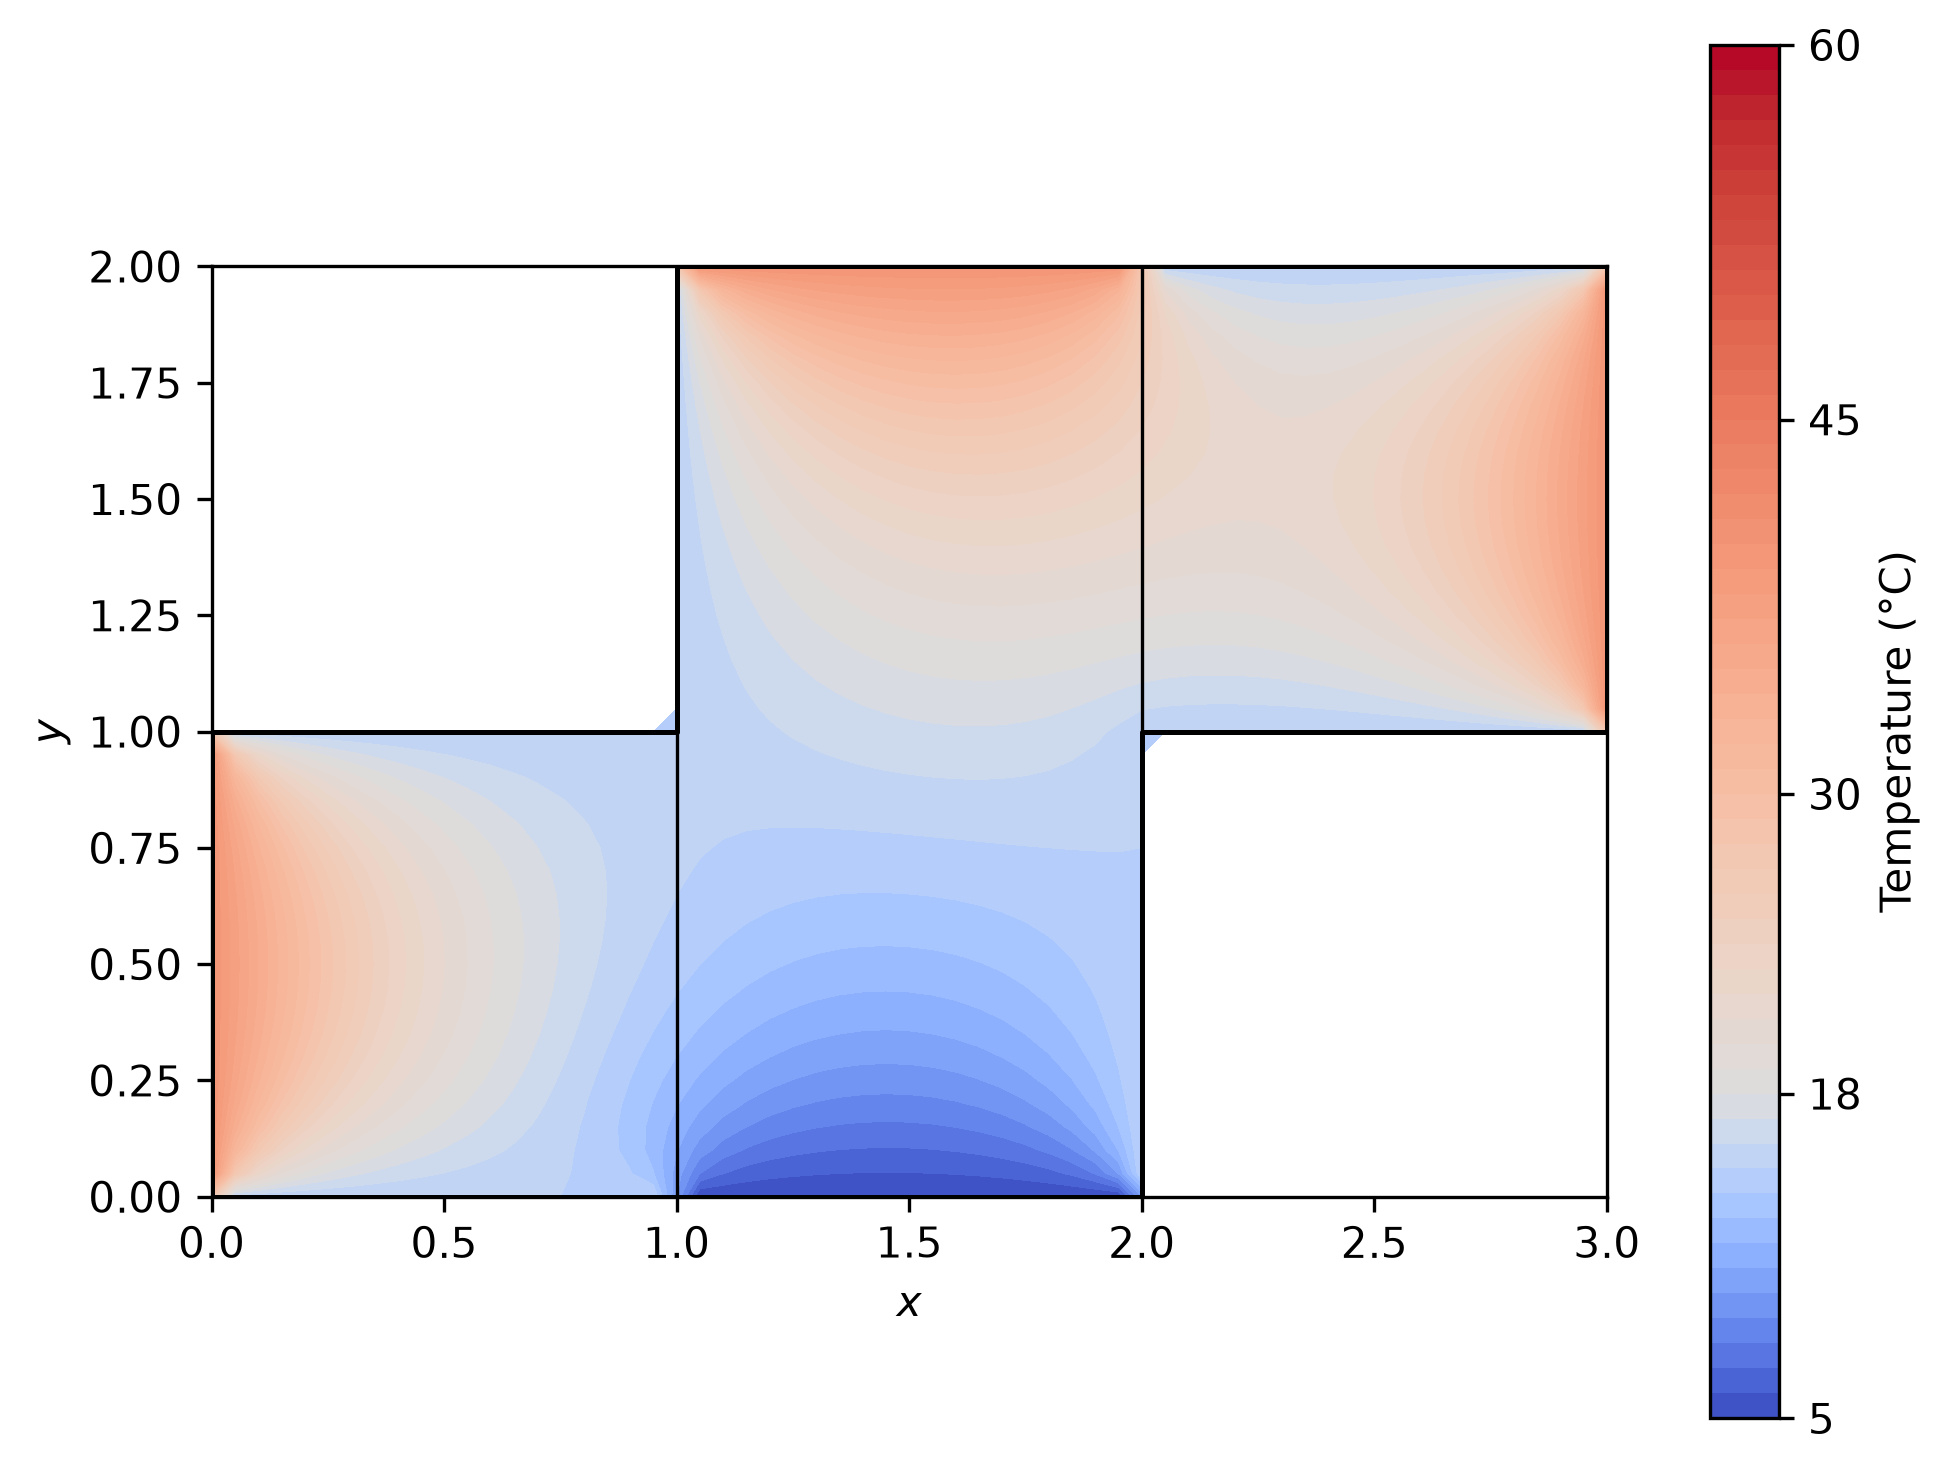

In [6]:
x = np.arange(apartment.shape[1]) * H
y = np.arange(apartment.shape[0]) * H
masked_temperature = np.ma.masked_invalid(apartment)

fig, ax = plt.subplots(dpi=300, layout="constrained")
contour = ax.contourf(
    x,
    y,
    masked_temperature,
    levels=TEMPERATURE_LEVELS,
    cmap="coolwarm",
    norm=TEMPERATURE_NORM,
)
ax.plot([0, 2, 2, 3, 3, 1, 1, 0, 0],
        [0, 0, 1, 1, 2, 2, 1, 1, 0], color="black", linewidth=1.2)
ax.plot([1, 1], [0, 1], color="black", linewidth=0.8)
ax.plot([2, 2], [1, 2], color="black", linewidth=0.8)
ax.set(xlabel="$x$", ylabel="$y$", aspect="equal")
fig.colorbar(
    contour,
    ax=ax,
    ticks=TEMPERATURE_TICKS,
    label="Temperature (°C)",
)
plt.show()

The coldest region is concentrated around the window at the bottom of $\Omega_2$. The three heaters raise the nearby temperatures, but their effect is not enough to keep the whole interior above 18°C after the prescribed ten iterations.

## Convergence check

We further check the convergence of the Dirichlet–Neumann iteration by plotting the maximum difference in interface temperatures at each iteration. The plot shows that the interface temperatures converge well after a few iterations, which means our Dirichlet–Neumann iteration is working as expected.

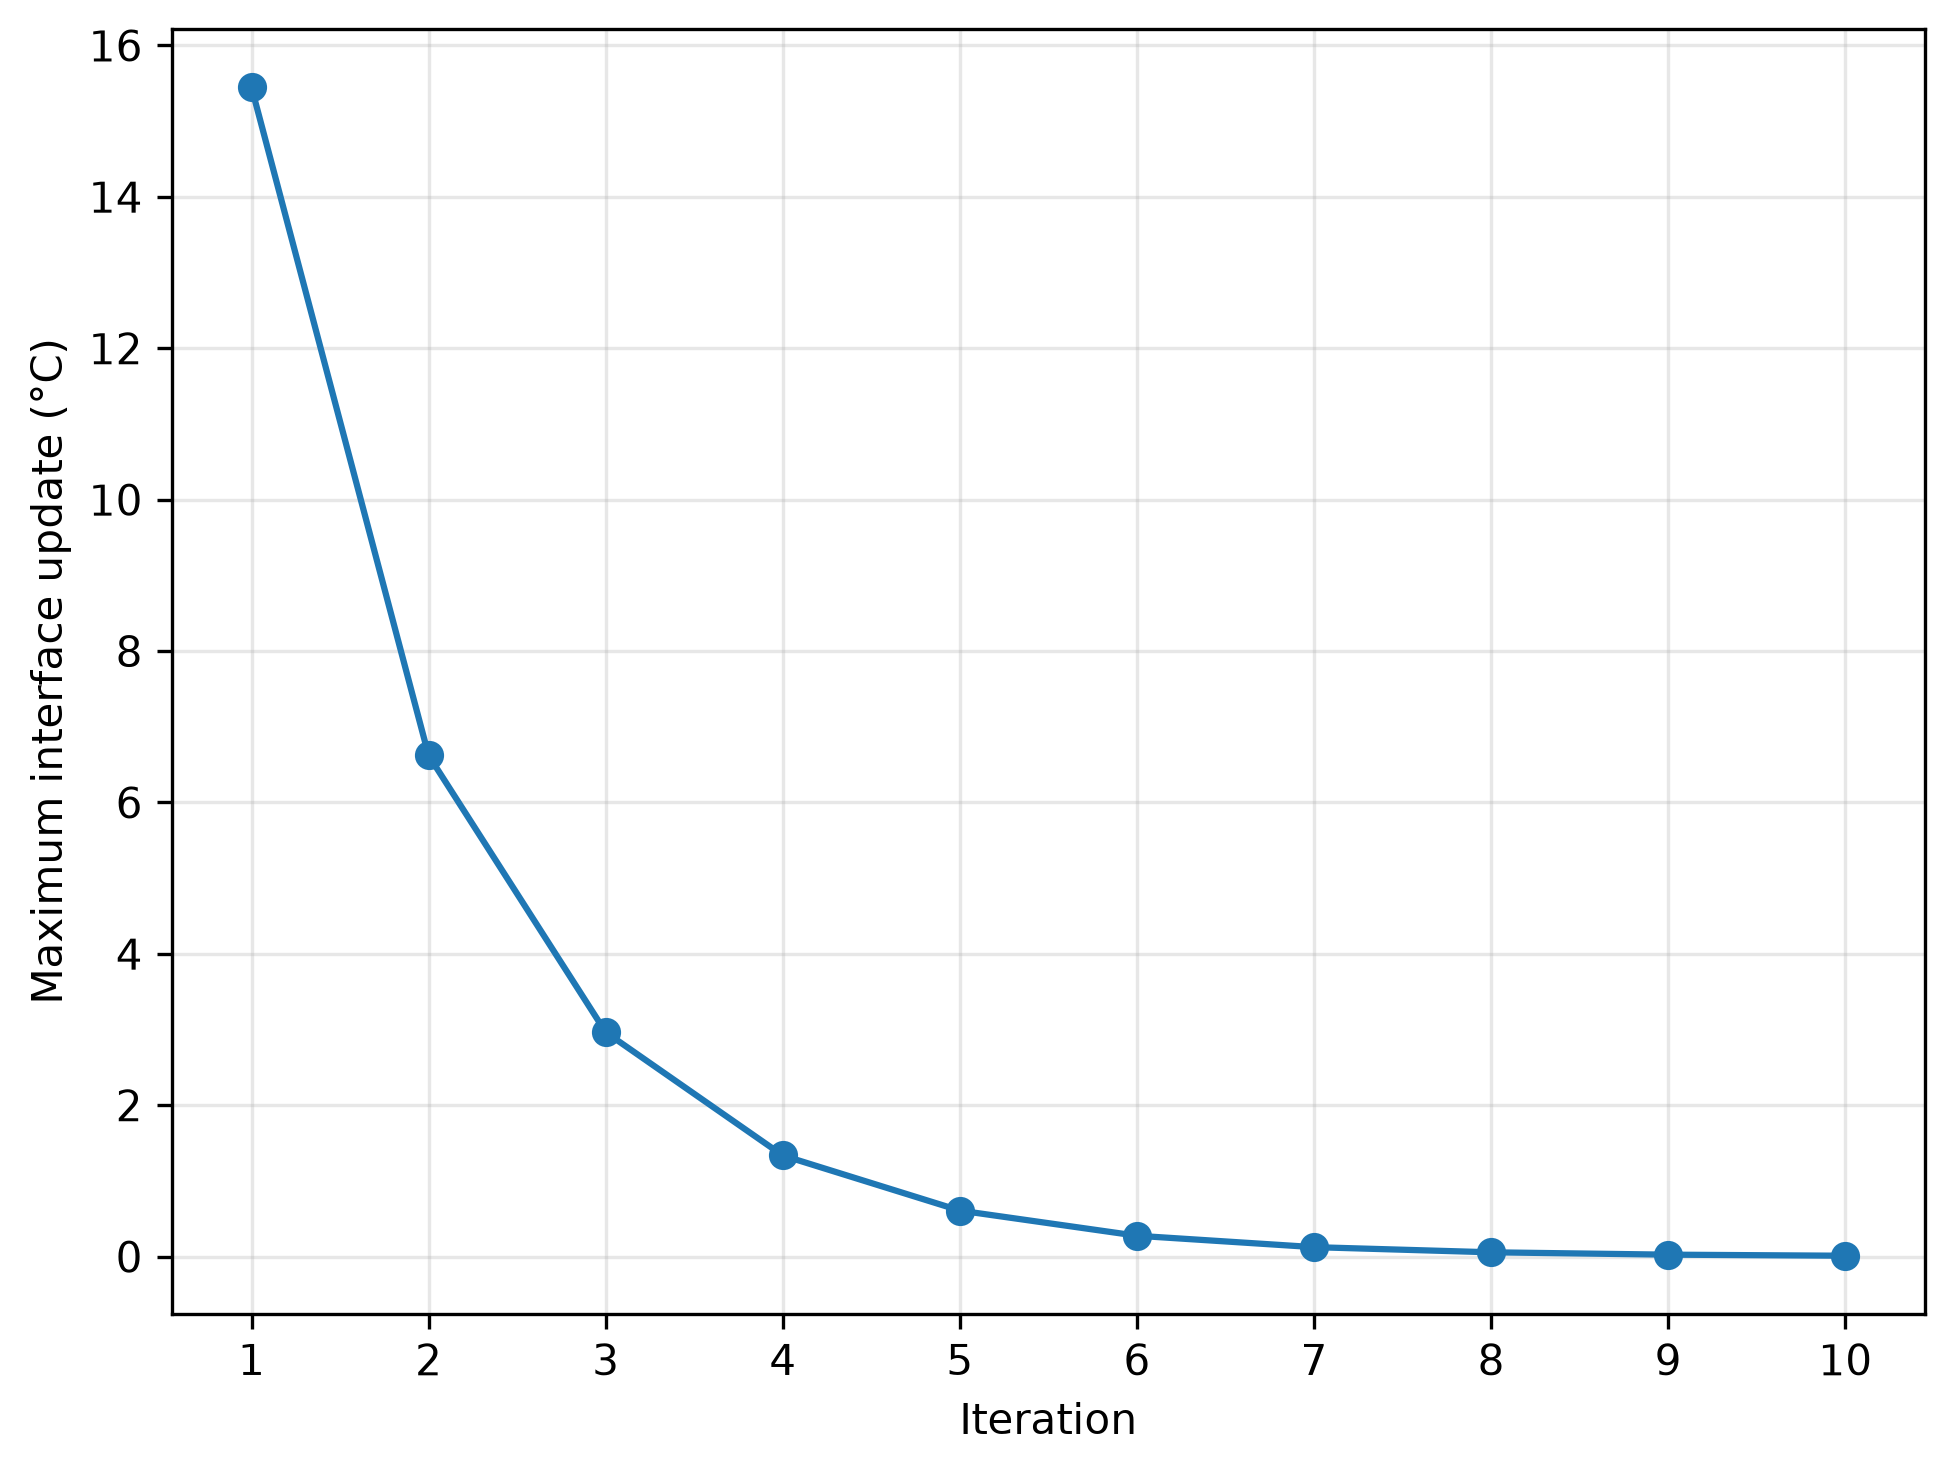

In [7]:
fig, ax = plt.subplots(dpi=300, layout="constrained")
iteration_numbers = np.arange(1, ITERATIONS + 1)
ax.plot(iteration_numbers, data["history"], marker="o")
ax.set(xlabel="Iteration", ylabel="Maximum interface update (°C)", xticks=iteration_numbers)
ax.grid(True, which="both", alpha=0.3)
plt.show()

## Task 4 — varying the heater temperature

We keep $h=1/20$, $\omega=0.8$, and compare heater temperatures of 40°C, 50°C, and 60°C. The iteration count is set to 20 to ensure convergence.

In [8]:
heater_cases = {}

for heater_temperature in (40.0, 50.0, 60.0):
    output = f"task4_heater_{int(heater_temperature)}.npz"
    heater_cases[heater_temperature] = run_case(output, heater=heater_temperature, iterations=20)

print(f"{'Heater':>8} {'Minimum':>10} {'Mean':>10} {'Below 18°C':>12}")
for heater_temperature, case in heater_cases.items():
    _, values = get_interior_values(case["u1"], case["u2"], case["u3"])
    print(
        f"{heater_temperature:7.0f}°C "
        f"{values.min():9.2f}°C "
        f"{values.mean():9.2f}°C "
        f"{np.mean(values < 18.0):11.1%}"
    )

Saved task4_heater_40.npz after 20 iterations
Saved task4_heater_50.npz after 20 iterations
Saved task4_heater_60.npz after 20 iterations
  Heater    Minimum       Mean   Below 18°C
     40°C      5.96°C     19.89°C       46.4%
     50°C      6.00°C     22.26°C       40.1%
     60°C      6.04°C     24.63°C       35.5%


Increasing the heater temperature raises the mean interior temperature and reduces the fraction of nodes below 18°C. However, the minimum changes very little because the coldest nodes remain close to the 5°C window.

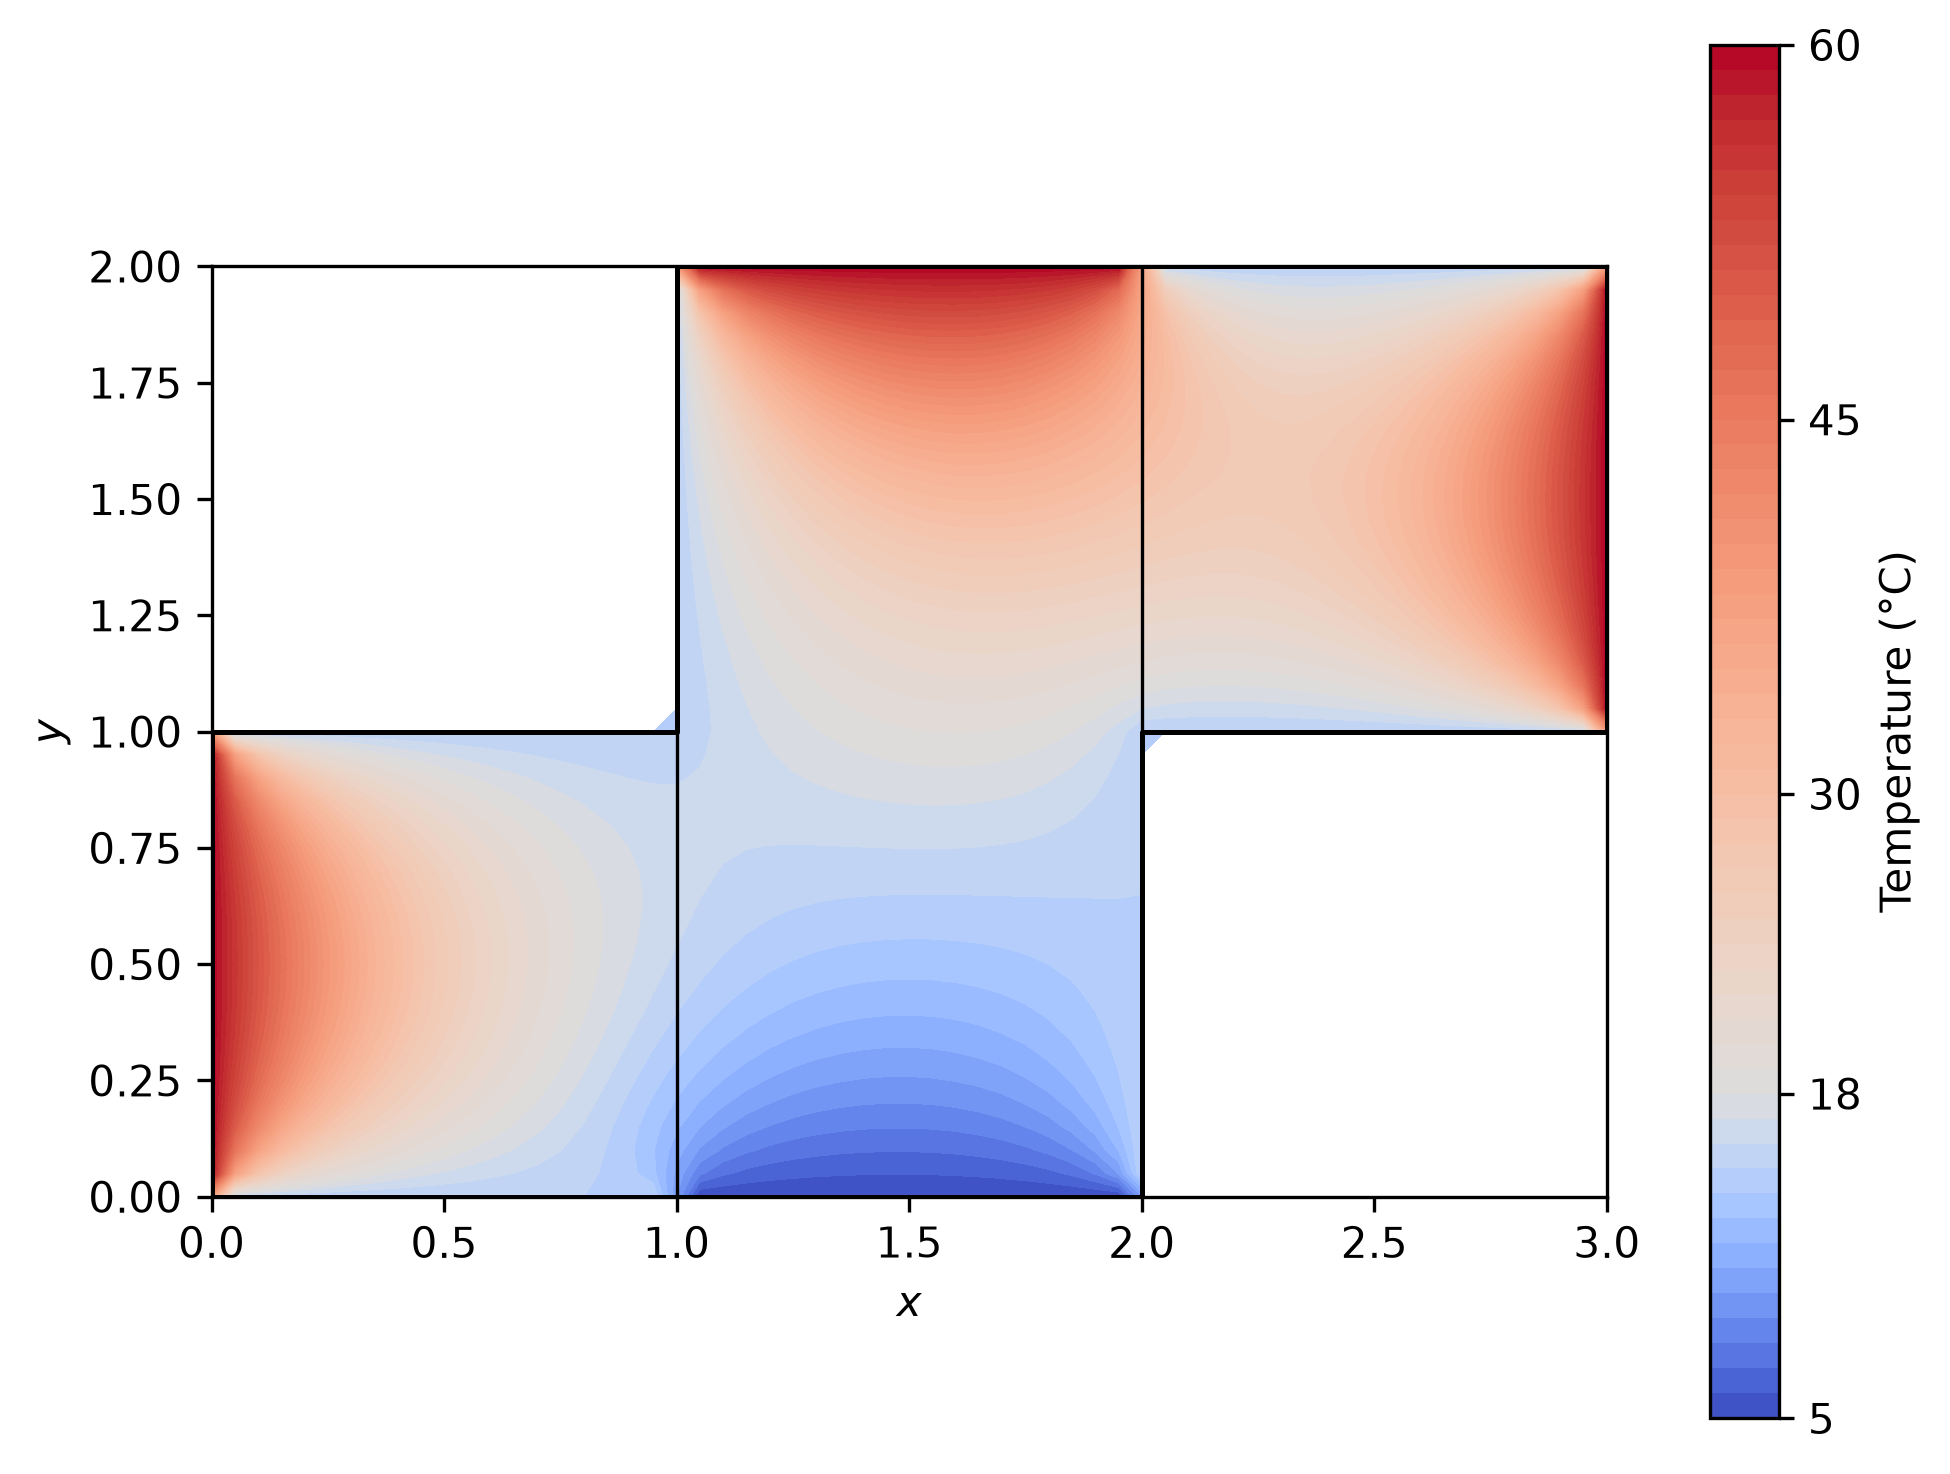

In [9]:
# Visualize the 60°C heater case

data = heater_cases[60.0]
u1, u2, u3 = data["u1"], data["u2"], data["u3"]
apartment, interior_values = get_interior_values(u1, u2, u3)

x = np.arange(apartment.shape[1]) * H
y = np.arange(apartment.shape[0]) * H
masked_temperature = np.ma.masked_invalid(apartment)

fig, ax = plt.subplots(dpi=300, layout="constrained")
contour = ax.contourf(
    x,
    y,
    masked_temperature,
    levels=TEMPERATURE_LEVELS,
    cmap="coolwarm",
    norm=TEMPERATURE_NORM,
)
ax.plot([0, 2, 2, 3, 3, 1, 1, 0, 0],
        [0, 0, 1, 1, 2, 2, 1, 1, 0], color="black", linewidth=1.2)
ax.plot([1, 1], [0, 1], color="black", linewidth=0.8)
ax.plot([2, 2], [1, 2], color="black", linewidth=0.8)
ax.set(xlabel="$x$", ylabel="$y$", aspect="equal")
fig.colorbar(
    contour,
    ax=ax,
    ticks=TEMPERATURE_TICKS,
    label="Temperature (°C)",
)
plt.show()

# Project 1a — the 2.5-room apartment

The bid on the 2-room flat failed, so we repeat the exercise on the new layout. A fourth
room $\Omega_4$, one quarter the area of $\Omega_1$, hangs off the right wall of $\Omega_2$
underneath $\Omega_3$ and brings a third interface $\Gamma_3$.

Everything below reuses the solver written for Project 1. The point of the add-on is to find
out how much of that code survives a change of layout, so we record what was reused, what had
to be generalised, and what genuinely had to be written from scratch.

## Geometry and boundary conditions

We keep the coordinate system of Project 1, $x \in [0,3]$ and $y \in [0,2]$.

| room | extent | interface |
| --- | --- | --- |
| $\Omega_1$ | $[0,1] \times [0,1]$ | $\Gamma_1$ along its right edge |
| $\Omega_2$ | $[1,2] \times [0,2]$ | Dirichlet data on $\Gamma_1$, $\Gamma_2$, $\Gamma_3$ |
| $\Omega_3$ | $[2,3] \times [1,2]$ | $\Gamma_2$ along its left edge |
| $\Omega_4$ | $[2, 5/2] \times [1/2, 1]$ | $\Gamma_3$ along its left edge |

$\Omega_4$ is $\tfrac12 \times \tfrac12$, which is one quarter of the area of $\Omega_1$ as
the handout requires.

Reading the figure, $\Omega_4$ touches $\Omega_2$ only through $\Gamma_3$. Its floor is a
heater, and its other three edges are normal walls at 15 °C — including its ceiling, which
separates it from $\Omega_3$ but is not marked as an interface in the handout. $\Omega_4$ is
therefore the "half room" of the 2.5-room apartment: reachable only from $\Omega_2$.

The right edge of $\Omega_2$ is now split into three segments:

- $1 \le y \le 2$: $\Gamma_2$, Dirichlet data from $\Omega_3$
- $\tfrac12 \le y \le 1$: $\Gamma_3$, Dirichlet data from $\Omega_4$
- $0 \le y \le \tfrac12$: an ordinary wall at 15 °C

**A new constraint on the mesh.** $\Omega_4$ has side $\tfrac12$, so it only lands on the grid
when $n = 1/\Delta x$ is even. The $\Delta x = 1/3$ used for Task 1 of Project 1 is not
admissible for this layout, and we use $\Delta x = 1/4$ for the matrices below.

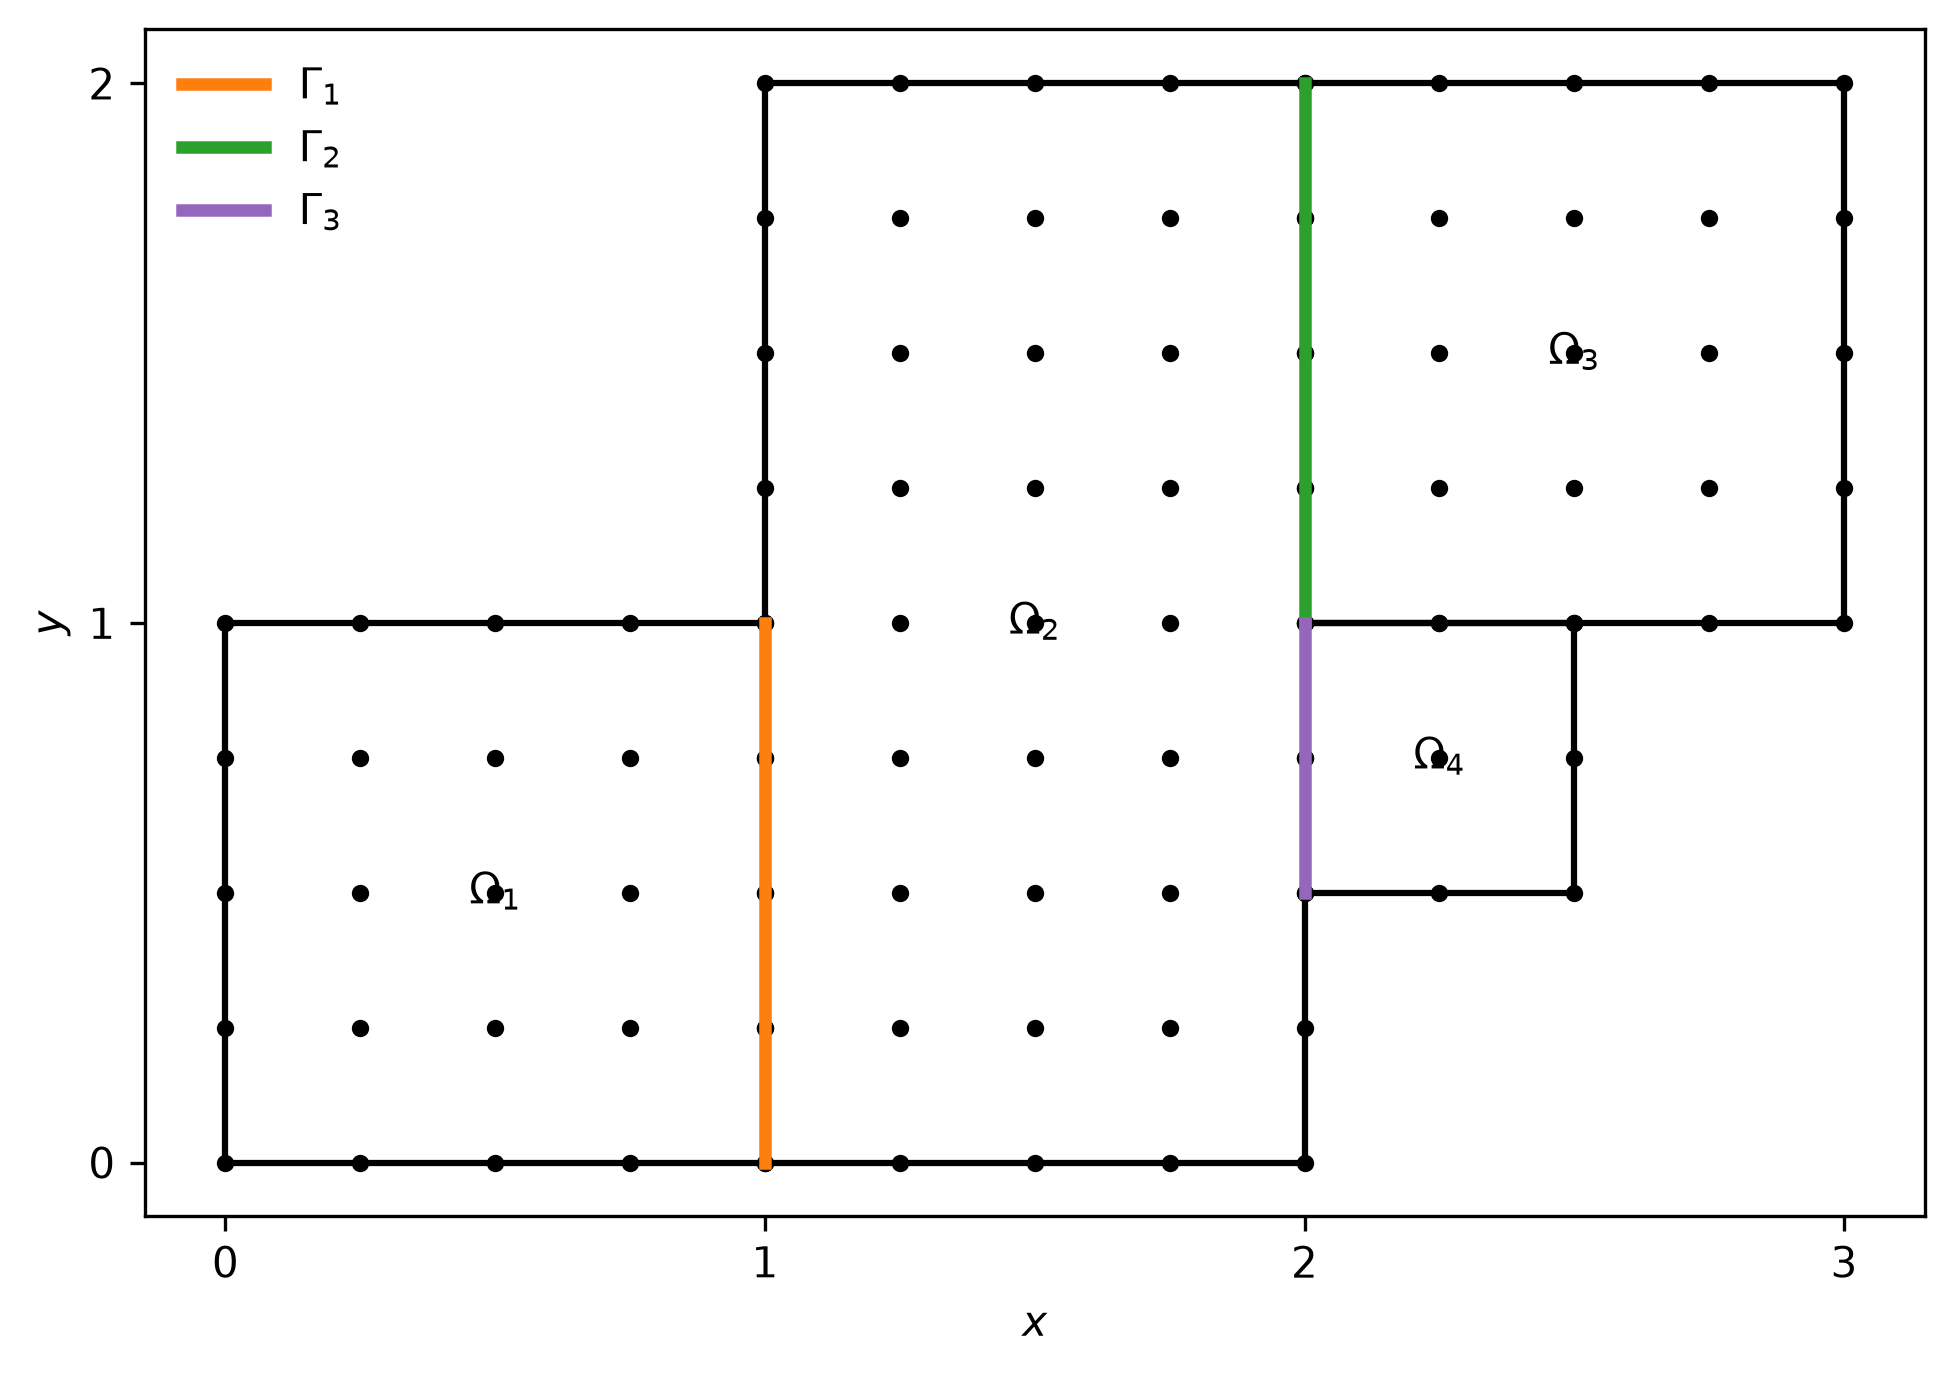

In [10]:
import time

from solver import assemble_apartment_half

h_small = 1 / 4  # n must be even so that Omega4 lands on the grid
fig, ax = plt.subplots(dpi=300, layout="constrained")

rooms = [
    (0, 1, 0, 1, r"$\Omega_1$"),
    (1, 2, 0, 2, r"$\Omega_2$"),
    (2, 3, 1, 2, r"$\Omega_3$"),
    (2, 2.5, 0.5, 1, r"$\Omega_4$"),
]
for x0, x1, y0, y1, label in rooms:
    x = np.arange(x0, x1 + h_small / 2, h_small)
    y = np.arange(y0, y1 + h_small / 2, h_small)
    X, Y = np.meshgrid(x, y)
    ax.scatter(X, Y, s=10, color="black")
    ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], color="black")
    ax.text((x0 + x1) / 2, (y0 + y1) / 2, label, ha="center", va="center")

ax.plot([1, 1], [0, 1], linewidth=3, color="tab:orange", label=r"$\Gamma_1$")
ax.plot([2, 2], [1, 2], linewidth=3, color="tab:green", label=r"$\Gamma_2$")
ax.plot([2, 2], [0.5, 1], linewidth=3, color="tab:purple", label=r"$\Gamma_3$")
ax.set(xlabel="$x$", ylabel="$y$", xticks=np.arange(4), yticks=np.arange(3))
ax.set_aspect("equal")
ax.legend(frameon=False, loc="upper left")
plt.show()

## What had to change in the code

The add-on asks whether the Project 1 code extends to a new layout or has to be rewritten.
Sorting the code by what happened to it:

**Reused unchanged.** The entire discretisation is layout-independent:

- `interior_index`, `dirichlet_b`, `outer_b` — the stencil and the right-hand side assembly.
- `dirichlet_matrix` — $A_2$ does not depend on *which* boundary nodes are walls and which are
  interfaces, only on which nodes are unknown. The middle-room matrix is built by exactly the
  same call as before, even though its boundary now carries three interface segments.
- `neumann_matrix` — $\Omega_4$ is still a square room whose interface runs along one full
  edge, so `neumann_matrix(m, "left")` produces $A_4$ with no change at all.
- `relax`, and the overall rank structure of the driver.

**Had to be generalised.** Three assumptions about the Project 1 layout were buried in the code:

1. `solve_center` and `solve_outer` each built their own boundary grid internally, which
   hardcoded the arrangement of heaters and walls. They now take a prepared boundary array, so
   a room with different walls is simply a different array.
2. `solve_outer` derived the mesh width as `1.0 / n` from the size of the room's own matrix.
   That is only correct while every room has side 1. $\Omega_4$ has side $\tfrac12$ resolved by
   $m = n/2$ intervals, so its mesh width is $1/n$, not $1/m$. `h` is now an explicit argument.
   This one mattered: left alone it would have silently used the wrong $h$ in the flux term
   $h\,q$ at $\Gamma_3$ and quietly produced a wrong answer.
3. `assemble_apartment` had the three room positions written out as literal array slices. It is
   now `assemble(placements, shape)`, taking a list of `(grid, row offset, column offset)`, and
   each layout is one short list.

**Genuinely new.** Only the code that *describes* the geometry:

- `center_boundary_half` — the right edge of $\Omega_2$ split into two interfaces and a wall.
- `small_room_boundary` — $\Omega_4$'s walls, with the heater along its floor.
- `interface_fluxes_half` — one additional flux slice.
- `mpi_driver_half.py` — four ranks instead of three.

So the numerics carried over completely and the geometry did not. The code was extendible, but
only after pulling three hardcoded layout assumptions out of functions that had no business
knowing about them.

## Task 1 — the matrices for the new layout

With $\Delta x = 1/4$ we have $n = 4$ and $m = n/2 = 2$. The unknown counts are

- $\Omega_1$ and $\Omega_3$: 12 each — three rows of four nodes. The interface column is
  included because on the Neumann side the interface temperature is itself unknown.
- $\Omega_2$: 21 — three columns of seven nodes, all four boundary edges being Dirichlet.
- $\Omega_4$: 2 — a single row of two nodes.

$A_2$ is the ordinary five-point matrix. $A_1$, $A_3$ and $A_4$ carry the flux-balance rows,
recognisable by the $3$ on the diagonal at each interface node.

In [11]:
n_small = 4
m_small = n_small // 2

A1_half = neumann_matrix(n_small, "right")
A2_half = dirichlet_matrix(n_small, 2 * n_small)
A3_half = neumann_matrix(n_small, "left")
A4_half = neumann_matrix(m_small, "left")

for name, matrix in (
    ("A1", A1_half),
    ("A2", A2_half),
    ("A3", A3_half),
    ("A4", A4_half),
):
    print(f"{name}: {matrix.shape[0]} x {matrix.shape[1]}")
    print(matrix)
    print()

A1: 12 x 12
[[ 4. -1.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  4. -1.  0.  0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  4. -1.  0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  3.  0.  0.  0. -1.  0.  0.  0.  0.]
 [-1.  0.  0.  0.  4. -1.  0.  0. -1.  0.  0.  0.]
 [ 0. -1.  0.  0. -1.  4. -1.  0.  0. -1.  0.  0.]
 [ 0.  0. -1.  0.  0. -1.  4. -1.  0.  0. -1.  0.]
 [ 0.  0.  0. -1.  0.  0. -1.  3.  0.  0.  0. -1.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.  4. -1.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0. -1.  4. -1.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.  0. -1.  4. -1.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.  0.  0. -1.  3.]]

A2: 21 x 21
[[ 4. -1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  4. -1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  4.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  0.  0.  4. -1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0. 

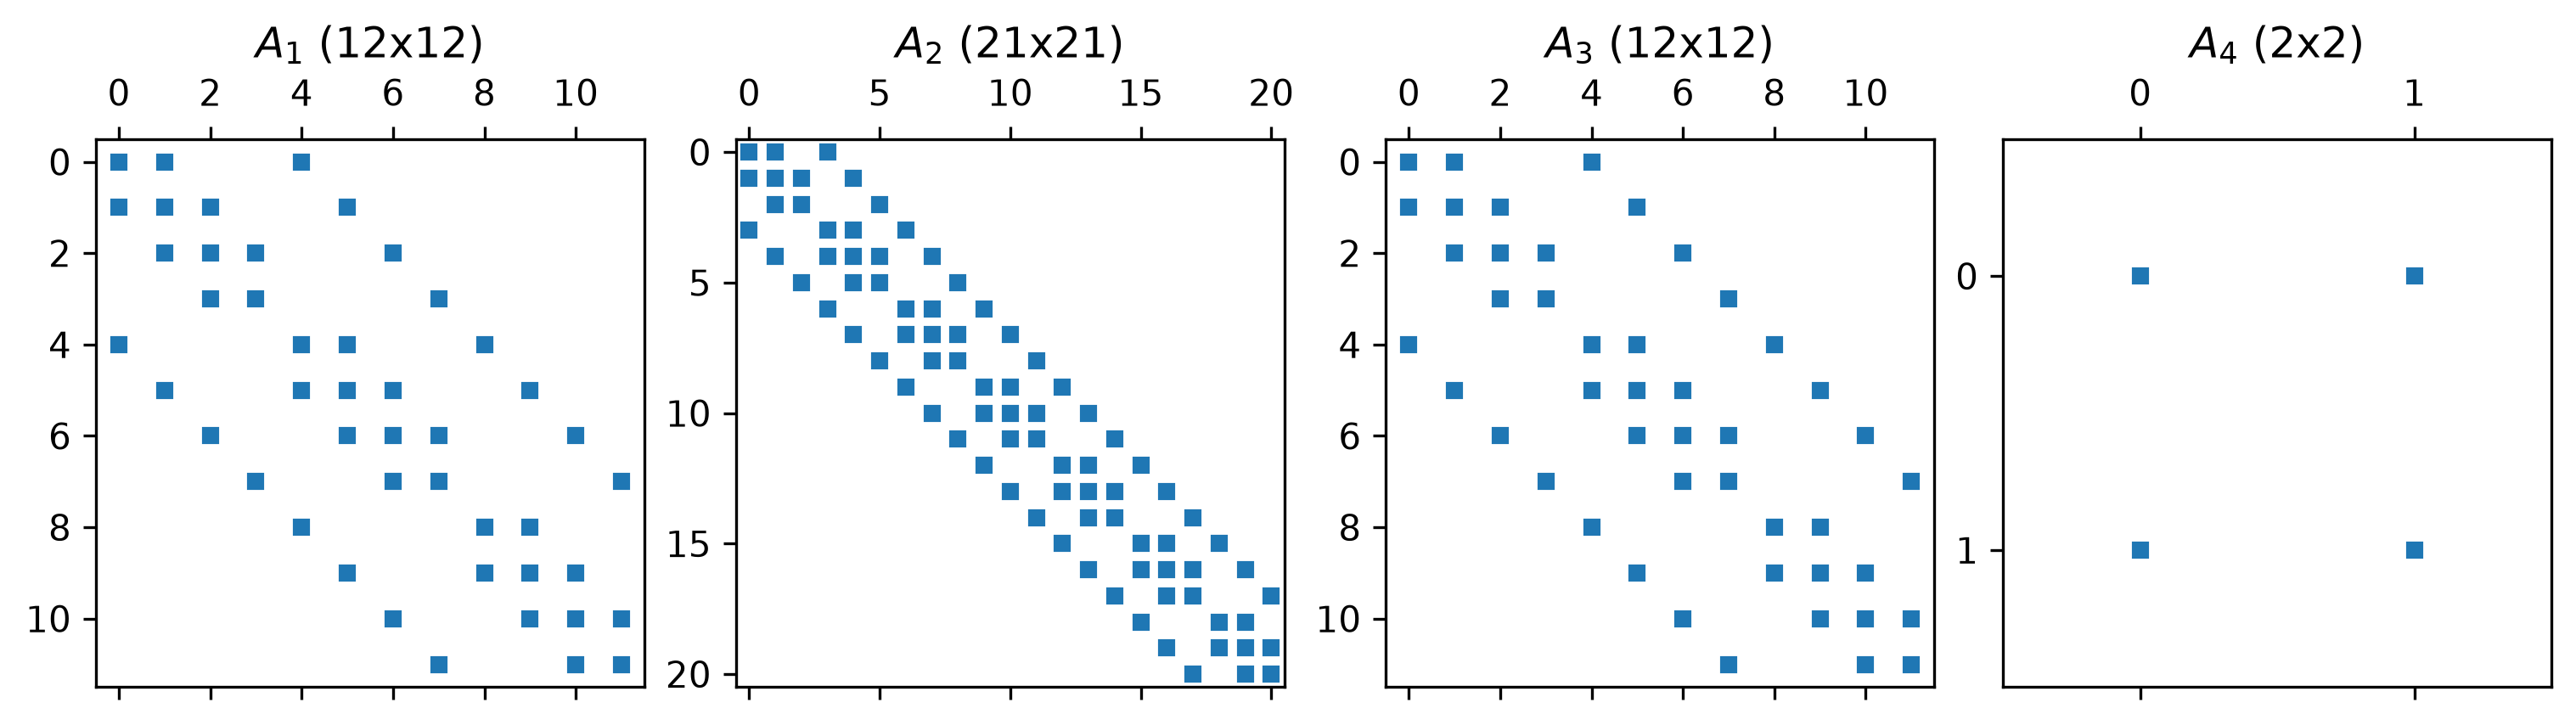

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(10, 3), dpi=300, layout="constrained")
for ax, (name, matrix) in zip(
    axes,
    (("$A_1$", A1_half), ("$A_2$", A2_half), ("$A_3$", A3_half), ("$A_4$", A4_half)),
):
    ax.spy(matrix, markersize=4)
    ax.set_title(f"{name} ({matrix.shape[0]}x{matrix.shape[0]})")
plt.show()

## Task 1 — solving the 2.5-room apartment

Four ranks now. Rank 0 holds $\Omega_2$ together with the three Dirichlet traces; ranks 1, 2
and 3 hold $\Omega_1$, $\Omega_3$ and $\Omega_4$ with their Neumann conditions. The exchange
pattern within one iteration is unchanged, only wider: rank 0 solves, sends three fluxes out,
and receives three interface temperatures back.

We keep $\Delta x = 1/20$, $\omega = 0.8$ and ten iterations so that the numbers are directly
comparable with Project 1.

In [13]:
def run_case_half(
    output,
    n=N,
    omega=OMEGA,
    iterations=ITERATIONS,
    wall=WALL_TEMPERATURE,
    heater=HEATER_TEMPERATURE,
    window=WINDOW_TEMPERATURE,
    sparse=False,
):
    command = [
        "mpiexec", "-n", "4", sys.executable, "mpi_driver_half.py",
        "--n", str(n),
        "--omega", str(omega),
        "--iterations", str(iterations),
        "--wall", str(wall),
        "--heater", str(heater),
        "--window", str(window),
        "--output", output,
    ]
    if sparse:
        command.append("--sparse")
    run = subprocess.run(command, capture_output=True, text=True, check=True)
    print(run.stdout.strip())
    return np.load(output)


data_half = run_case_half("temperature_half.npz")

Saved temperature_half.npz after 10 iterations


### Is the heating adequate?

We apply the same 18 °C threshold and the same interior-node selection as in Task 2 of
Project 1. The Project 1 baseline is reloaded from its saved file rather than taken from a
variable, so this comparison does not depend on which case the earlier cells happened to leave
behind.

In [14]:
def interior_values(apartment):
    """Return the interior node values of an assembled apartment."""
    present = np.isfinite(apartment)
    interior = present.copy()
    interior[[0, -1], :] = False
    interior[:, [0, -1]] = False
    interior &= (
        np.roll(present, 1, axis=0)
        & np.roll(present, -1, axis=0)
        & np.roll(present, 1, axis=1)
        & np.roll(present, -1, axis=1)
    )
    return apartment[interior]


def summarize(apartment, label):
    values = interior_values(apartment)
    print(
        f"{label:<12} min {values.min():6.2f}  "
        f"mean {values.mean():6.2f}  below 18 C {np.mean(values < 18.0):6.1%}"
    )


baseline = np.load("temperature_data.npz")
apartment_baseline = assemble_apartment(
    baseline["u1"], baseline["u2"], baseline["u3"]
)
apartment_half = assemble_apartment_half(
    data_half["u1"], data_half["u2"], data_half["u3"], data_half["u4"]
)

summarize(apartment_baseline, "2 rooms")
summarize(apartment_half, "2.5 rooms")
print(f"\nLast interface update: {data_half['history'][-1]:.3f} C")

2 rooms      min   5.96  mean  19.89  below 18 C  46.4%
2.5 rooms    min   6.11  mean  20.54  below 18 C  39.8%

Last interface update: 0.012 C


The extra half-room helps, but it does not fix the flat. Its heater lifts the interior mean by
roughly 0.6 °C and pulls the fraction below 18 °C down from 46 % to 40 %, both because
$\Omega_4$ is itself warm and because it feeds heat back into the lower right of $\Omega_2$
through $\Gamma_3$.

The minimum barely moves (5.96 °C to 6.11 °C). The coldest nodes still sit directly against the
5 °C window at the bottom of $\Omega_2$, which is the far corner of the apartment from every
heater, and a node adjacent to a fixed 5 °C boundary cannot be rescued from across the room. So
the verdict is the same as in Project 1 — the heating is **not** adequate, and for the same
reason: the window, not the heaters, sets the minimum.

## Task 1 — temperature distribution

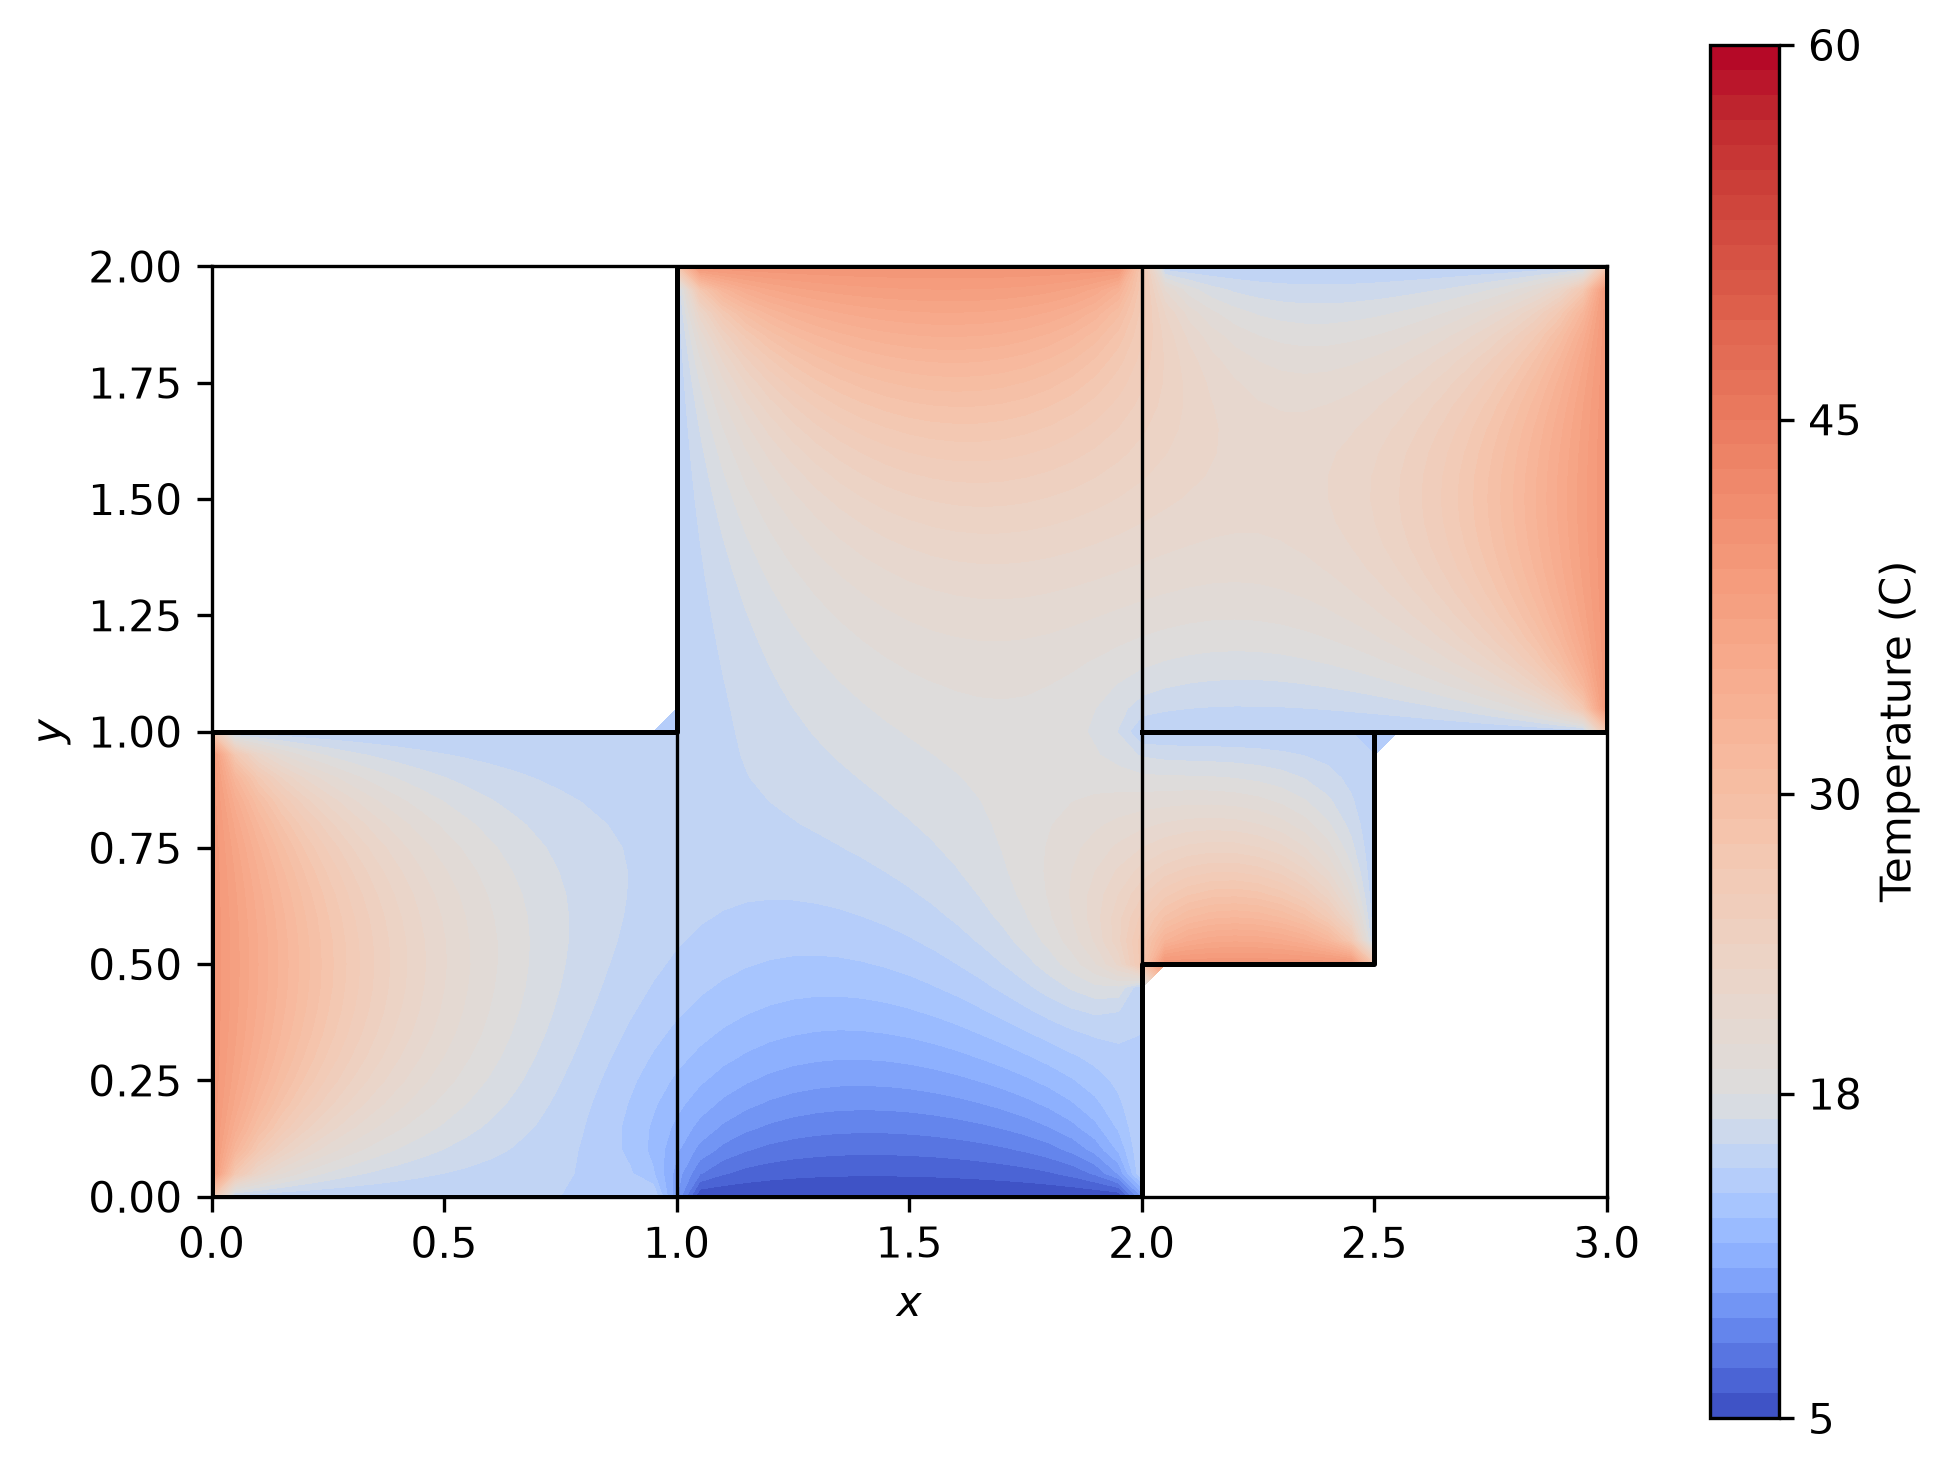

In [15]:
def plot_apartment(apartment, h, ax):
    """Draw an assembled 2.5-room apartment as a filled contour plot."""
    x = np.arange(apartment.shape[1]) * h
    y = np.arange(apartment.shape[0]) * h
    contour = ax.contourf(
        x,
        y,
        np.ma.masked_invalid(apartment),
        levels=TEMPERATURE_LEVELS,
        cmap="coolwarm",
        norm=TEMPERATURE_NORM,
    )
    # Exterior outline
    ax.plot(
        [0, 2, 2, 2.5, 2.5, 3, 3, 1, 1, 0, 0],
        [0, 0, 0.5, 0.5, 1, 1, 2, 2, 1, 1, 0],
        color="black",
        linewidth=1.2,
    )
    ax.plot([2, 2.5], [1, 1], color="black", linewidth=1.2)  # Omega3 / Omega4 wall
    ax.plot([1, 1], [0, 1], color="black", linewidth=0.8)  # Gamma1
    ax.plot([2, 2], [1, 2], color="black", linewidth=0.8)  # Gamma2
    ax.plot([2, 2], [0.5, 1], color="black", linewidth=0.8)  # Gamma3
    ax.set(xlabel="$x$", ylabel="$y$", aspect="equal")
    return contour


fig, ax = plt.subplots(dpi=300, layout="constrained")
contour = plot_apartment(apartment_half, H, ax)
fig.colorbar(contour, ax=ax, ticks=TEMPERATURE_TICKS, label="Temperature (C)")
plt.show()

### Convergence

The interface update decays geometrically, so the iteration is a genuine contraction. Plotting
it on a logarithmic axis makes the constant factor per iteration visible as a straight line.

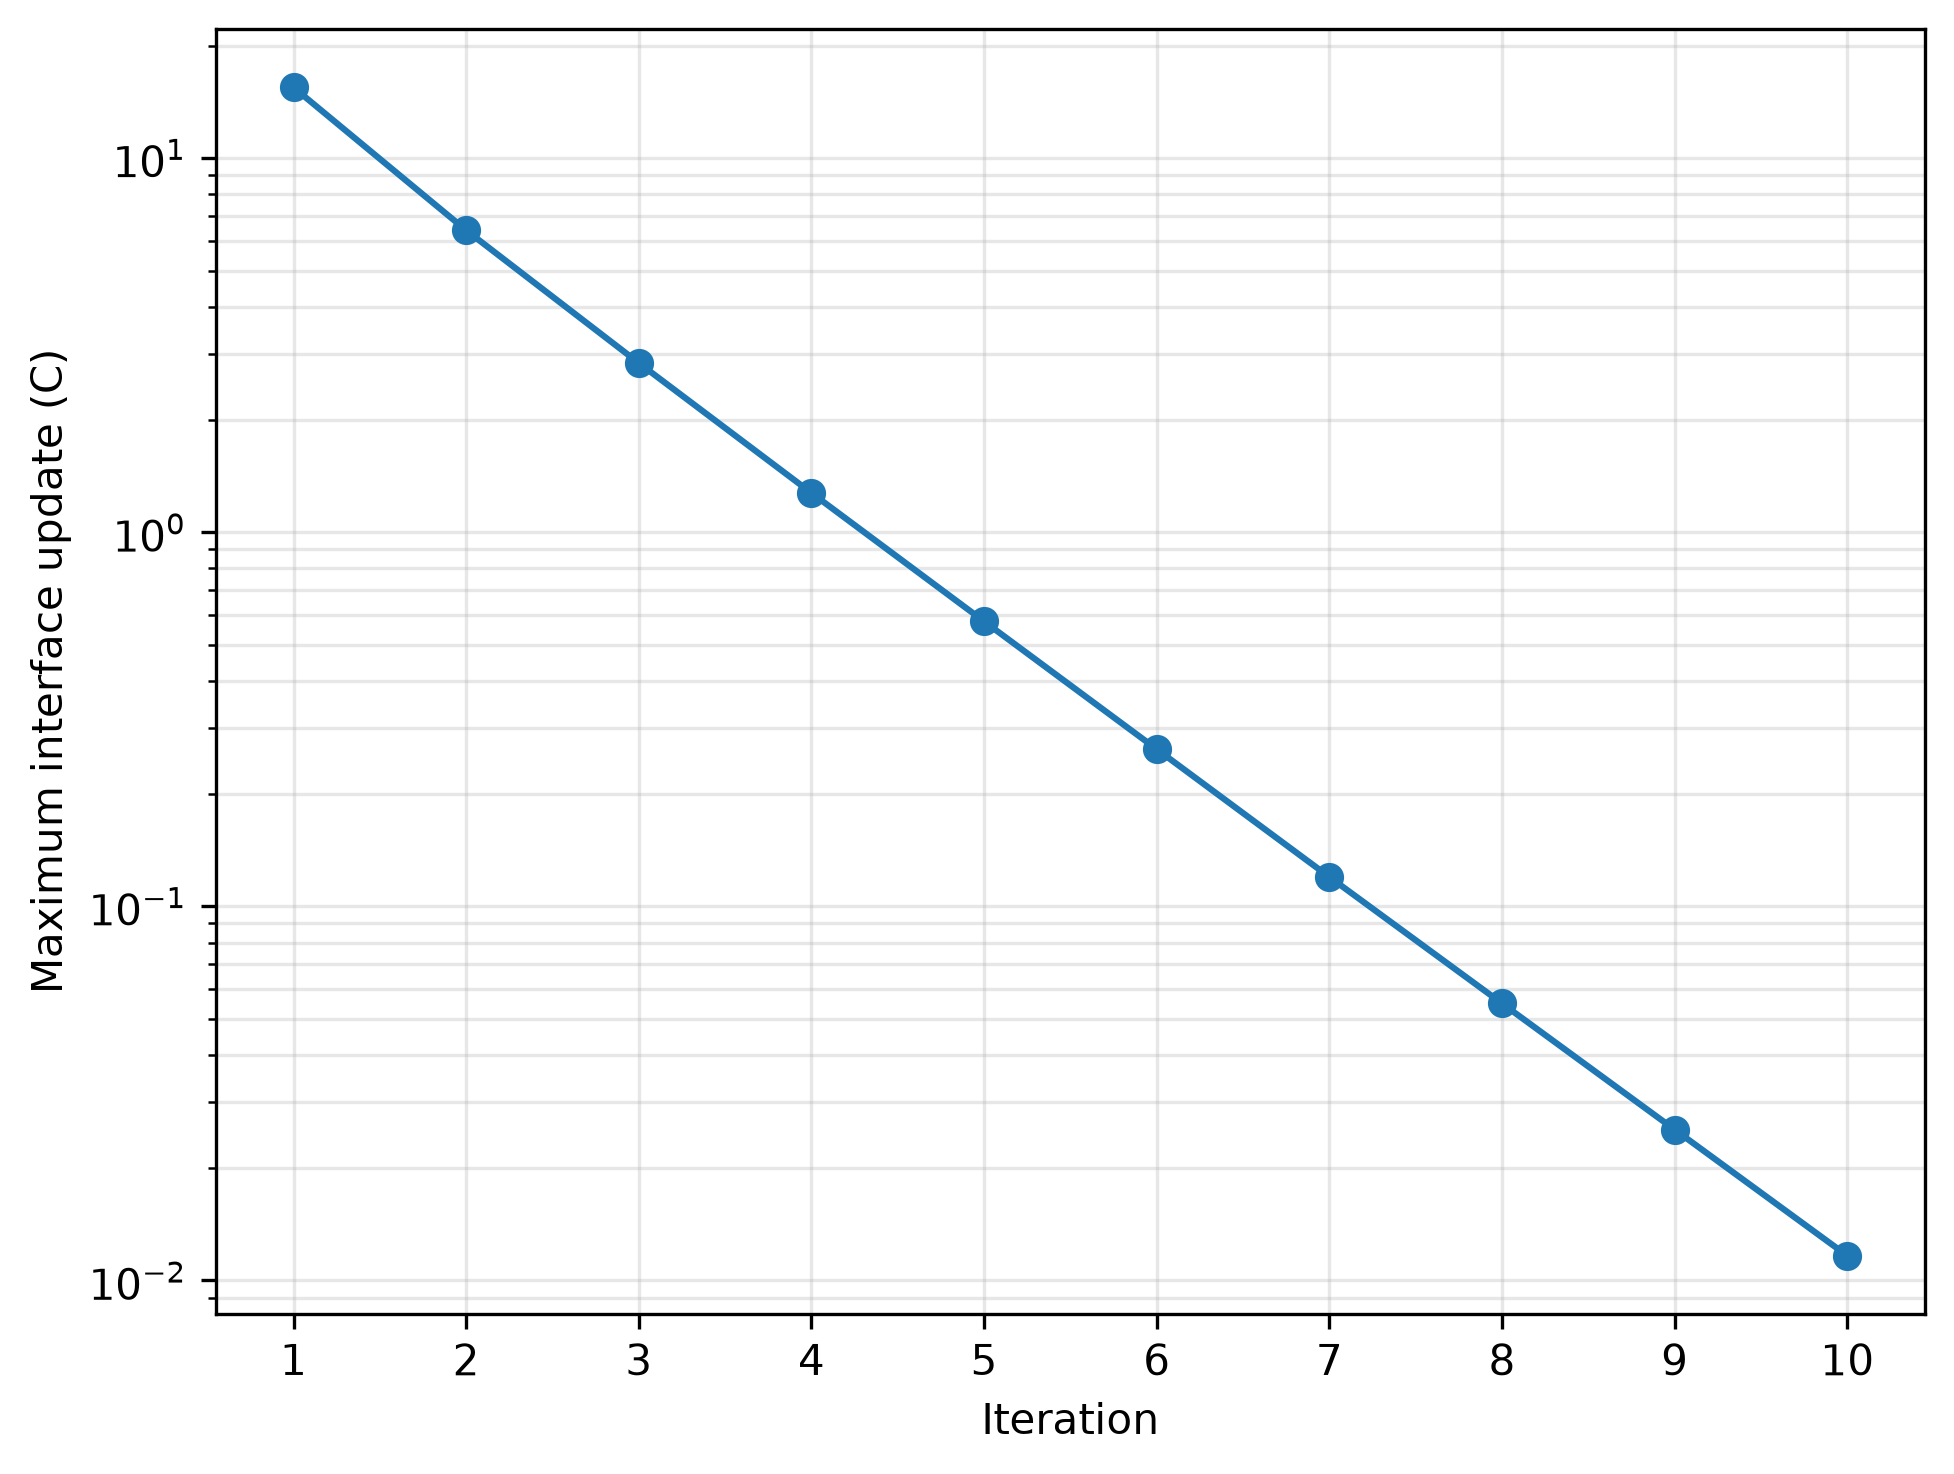

In [16]:
fig, ax = plt.subplots(dpi=300, layout="constrained")
iteration_numbers = np.arange(1, len(data_half["history"]) + 1)
ax.semilogy(iteration_numbers, data_half["history"], marker="o")
ax.set(
    xlabel="Iteration",
    ylabel="Maximum interface update (C)",
    xticks=iteration_numbers,
)
ax.grid(True, which="both", alpha=0.3)
plt.show()

## Task 2 — computing with $\Delta x = 1/100$

At $\Delta x = 1/100$ the middle room has $99 \times 199 = 19\,701$ unknowns. `scipy.linalg.solve`
requires a dense matrix, so $A_2$ alone would occupy

$$19\,701^2 \times 8 \text{ bytes} \approx 2.9\ \text{GB},$$

before the LU factorisation allocates a working copy of its own, and $\Omega_1$ and $\Omega_3$
would want a further 0.73 GB each. This is exactly where the Project 1 approach stops — not
because the method breaks down, but because storing a matrix that is over 99.9 % zeros is
hopeless.

The fix is to store only the non-zeros. Every row of the five-point stencil has at most five
entries, so $A_2$ holds about $10^5$ of them instead of $3.9 \times 10^8$ array slots. The
matrix builders now collect their entries as `(row, column, value)` triplets and hand them to
either a dense array or a `scipy.sparse` matrix, and `solve_system` dispatches to
`scipy.linalg.solve` or `scipy.sparse.linalg.spsolve` to match. The stencil logic is untouched:
this is a change of storage, not of method.

In [17]:
print(f"{'room':<18}{'unknowns':>10}{'dense':>12}{'sparse':>12}")
for label, unknowns in (
    ("Omega1 / Omega3", 99 * 100),
    ("Omega2", 99 * 199),
    ("Omega4", 49 * 50),
):
    dense_gb = unknowns**2 * 8 / 1024**3
    sparse_mb = unknowns * 5 * 12 / 1024**2
    print(f"{label:<18}{unknowns:10d}{dense_gb:10.2f} GB{sparse_mb:10.2f} MB")

room                unknowns       dense      sparse
Omega1 / Omega3         9900      0.73 GB      0.57 MB
Omega2                 19701      2.89 GB      1.13 MB
Omega4                  2450      0.04 GB      0.14 MB


Ten iterations are no longer enough on the fine mesh, so we run 30 (the reason is examined
below).

In [18]:
N_FINE = 100
H_FINE = 1 / N_FINE
ITERATIONS_FINE = 30

start = time.perf_counter()
data_fine = run_case_half(
    "temperature_half_fine.npz",
    n=N_FINE,
    iterations=ITERATIONS_FINE,
    sparse=True,
)
print(f"Wall time: {time.perf_counter() - start:.1f} s")

apartment_fine = assemble_apartment_half(
    data_fine["u1"], data_fine["u2"], data_fine["u3"], data_fine["u4"]
)
summarize(apartment_half, "dx = 1/20")
summarize(apartment_fine, "dx = 1/100")

Saved temperature_half_fine.npz after 30 iterations
Wall time: 5.6 s
dx = 1/20    min   6.11  mean  20.54  below 18 C  39.8%
dx = 1/100   min   5.22  mean  20.65  below 18 C  40.4%


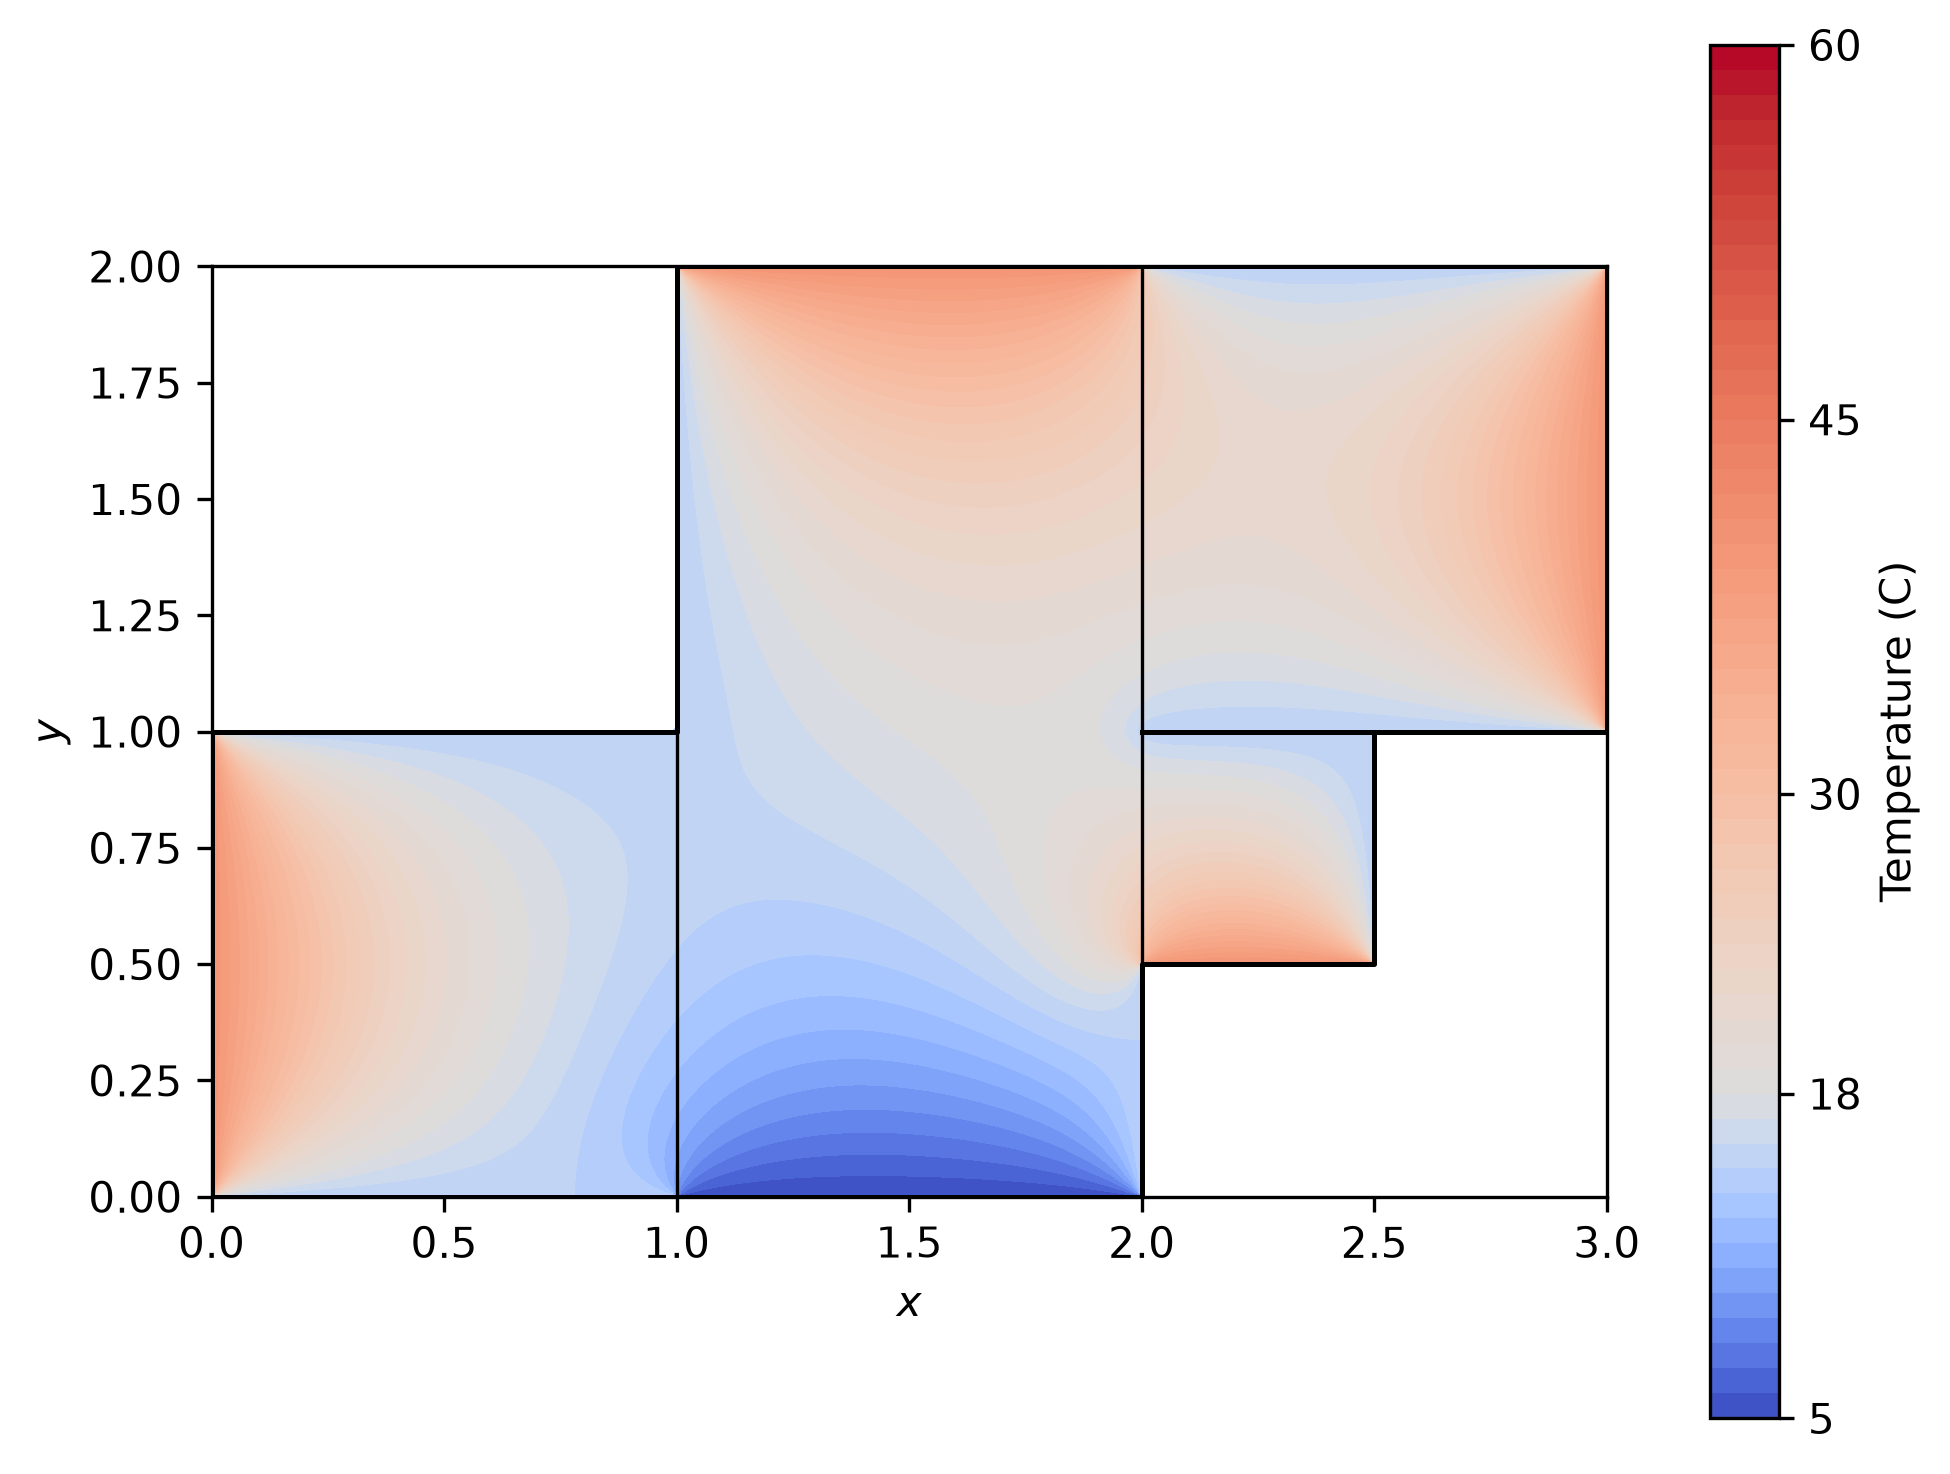

In [19]:
fig, ax = plt.subplots(dpi=300, layout="constrained")
contour = plot_apartment(apartment_fine, H_FINE, ax)
fig.colorbar(contour, ax=ax, ticks=TEMPERATURE_TICKS, label="Temperature (C)")
plt.show()

### How the mesh affects the iteration count

The Dirichlet–Neumann iteration is a fixed-point iteration on the interface temperatures, and
its contraction factor depends on the mesh. Running both meshes for the same 30 iterations
shows the effect directly.

Saved temperature_half_long.npz after 30 iterations


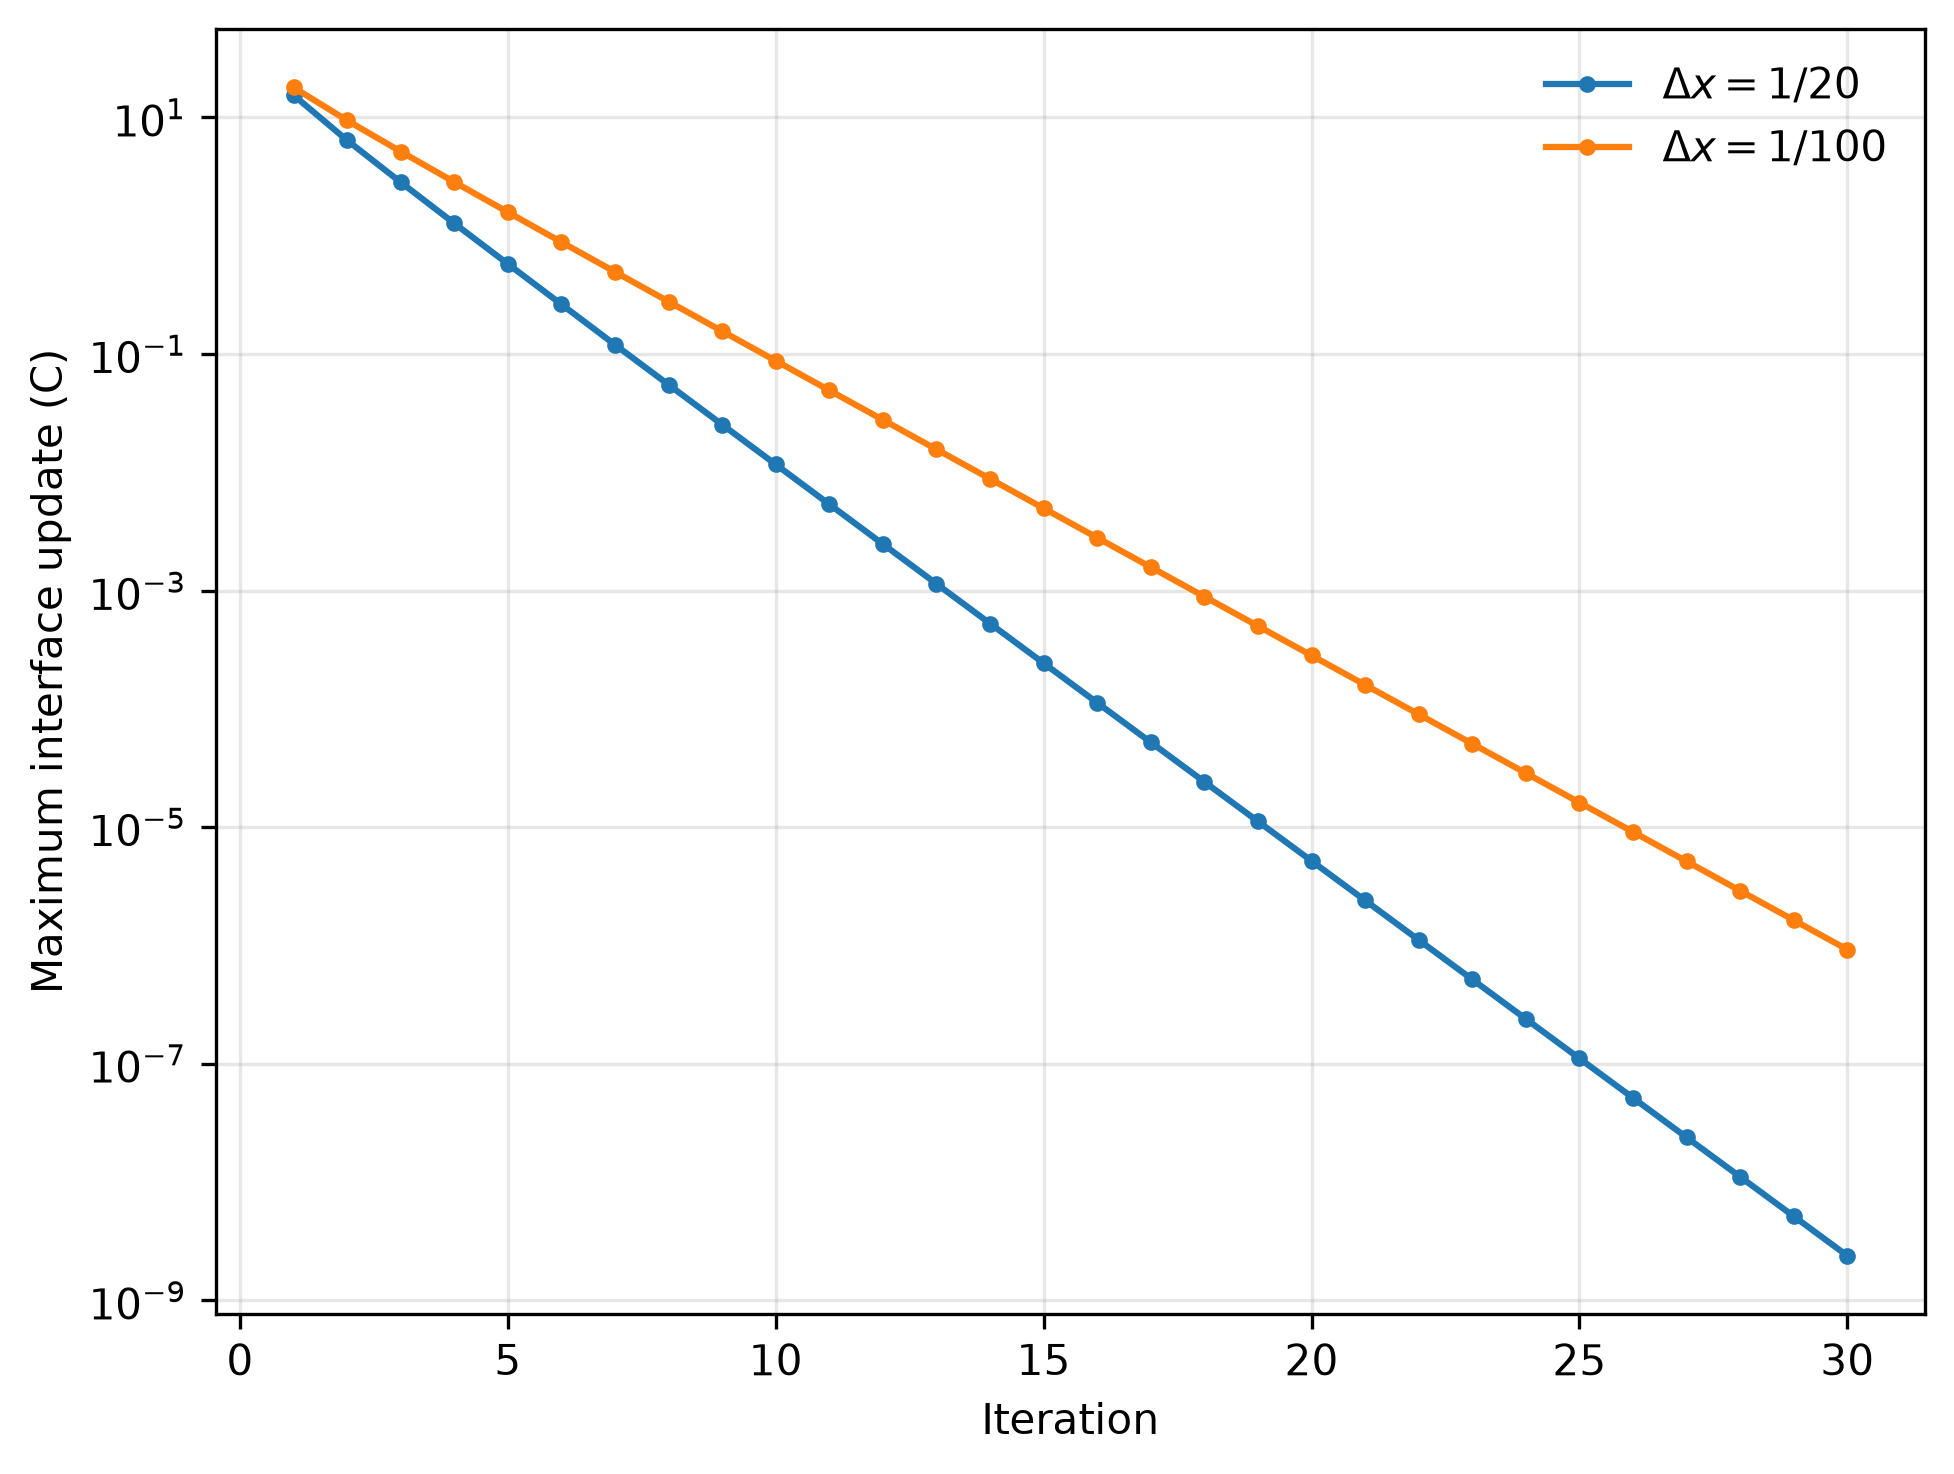

   tolerance   dx = 1/20  dx = 1/100
         0.1           8          10
        0.01          11          14
       0.001          14          18


In [20]:
data_half_long = run_case_half(
    "temperature_half_long.npz", iterations=ITERATIONS_FINE
)

fig, ax = plt.subplots(dpi=300, layout="constrained")
for history, label in (
    (data_half_long["history"], r"$\Delta x = 1/20$"),
    (data_fine["history"], r"$\Delta x = 1/100$"),
):
    ax.semilogy(np.arange(1, len(history) + 1), history, marker="o", markersize=3, label=label)
ax.set(xlabel="Iteration", ylabel="Maximum interface update (C)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(frameon=False)
plt.show()


def iterations_to(history, tolerance):
    reached = np.where(history < tolerance)[0]
    return int(reached[0]) + 1 if reached.size else None


print(f"{'tolerance':>12}{'dx = 1/20':>12}{'dx = 1/100':>12}")
for tolerance in (1e-1, 1e-2, 1e-3):
    print(
        f"{tolerance:12g}"
        f"{iterations_to(data_half_long['history'], tolerance):12d}"
        f"{iterations_to(data_fine['history'], tolerance):12d}"
    )

### Conclusion for Task 2

With sparse matrices $\Delta x = 1/100$ runs in a few seconds, so the refinement is entirely
affordable once the storage is right. The temperature field is the same picture as at
$\Delta x = 1/20$, only better resolved: the interior mean shifts by about 0.1 °C, which is the
discretisation error of the coarse mesh, and the minimum drops slightly because the fine grid
places nodes closer to the cold window.

Both meshes converge geometrically, but not at the same rate — roughly a factor 0.46 per
iteration at $\Delta x = 1/20$ against 0.56 at $\Delta x = 1/100$. In practice that is a mild
penalty: reaching an interface update below $10^{-3}$ °C takes 14 iterations on the coarse mesh
and 18 on the fine one. Refining the mesh therefore costs more per iteration *and* a few more
iterations, but the iteration count does not blow up, which is the property that makes the
Dirichlet–Neumann method worth using.